### Les librairies :

In [117]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [108]:
mainpath = "xxx"
df = pd.read_csv(mainpath + "used_cars_data_shorter.csv")
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

In [4]:
df_train.info()
df_train.shape

<class 'pandas.DataFrame'>
Index: 725731 entries, 762868 to 121958
Data columns (total 43 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   vin                   725731 non-null  str    
 1   back_legroom          688661 non-null  str    
 2   bed_length            101988 non-null  str    
 3   body_type             721941 non-null  str    
 4   city_fuel_economy     616795 non-null  float64
 5   combine_fuel_economy  0 non-null       float64
 6   daysonmarket          725731 non-null  int64  
 7   engine_cylinders      702565 non-null  str    
 8   engine_displacement   683342 non-null  float64
 9   engine_type           702565 non-null  str    
 10  fleet                 270562 non-null  object 
 11  franchise_dealer      725731 non-null  bool   
 12  franchise_make        661548 non-null  str    
 13  front_legroom         688661 non-null  str    
 14  fuel_tank_volume      688661 non-null  str    
 15  fuel_type  

(725731, 43)

La base de données possède 43 variables et 725 731 observations en tout, que nous regardons une par une.

### EDA variable par variable :

**1. 'vin'**

In [5]:
print(df_train['vin'].head())
print(df_train['vin'].isna().value_counts(normalize=True))
df_train['vin'].nunique()

762868    3GKALVEXXLL128417
579012    1G1FW6S03H4153557
668443    3GNCJLSB4LL223926
692273    2T3H1RFV6LC069283
885904    4T1C11AK8LU387549
Name: vin, dtype: str
vin
False    1.0
Name: proportion, dtype: float64


725728

'vin' est un ID différent pour chaque observations, il a quasiment autant de valeurs que d'observations,3 ID seraient identique, nous enlevons donc de potentiel doublons. Puis nous supprimons la variable 'vin' de la base car elle est inutile pour le modèle.

In [6]:
df_train = df_train.drop_duplicates()
df_train = df_train.drop(["vin"], axis =1)
df_train.shape

(725728, 42)

**2. 'back_legroom'**

In [7]:
print(df_train['back_legroom'].unique())
print(df_train['back_legroom'].isna().value_counts(normalize=True))
(df_train['back_legroom'] == "--").value_counts(normalize=True)

<StringArray>
['39.7 in',       nan, '35.7 in', '37.8 in',   '38 in', '36.4 in', '43.6 in',
 '33.3 in', '35.1 in',   '39 in',
 ...
 '59.8 in',   '27 in', '45.1 in',   '49 in',   '25 in', '43.9 in', '28.7 in',
 '31.5 in', '53.1 in',   '24 in']
Length: 199, dtype: str
back_legroom
False    0.94892
True     0.05108
Name: proportion, dtype: float64


back_legroom
False    0.972801
True     0.027199
Name: proportion, dtype: float64

Environ 5% de valeurs manquantes, cette variable pourrait être quantitative plutot que quantitative si on retire les "in". On remarque aussi des "--" que l'on remplace par des valeurs manquantes (on passe donc à 7,8% de valeurs manquantes).

In [8]:
df_train['back_legroom (in)'] = (
    df_train['back_legroom']
    .str.replace(" in", "", regex=False)
    .replace("--", np.nan , regex=False)
    .astype(float)
)
df_train = df_train.drop(["back_legroom"], axis =1)
df_train['back_legroom (in)'].describe()

count    668919.000000
mean         38.139303
std           3.008584
min           0.000000
25%          36.100000
50%          38.300000
75%          39.900000
max          59.800000
Name: back_legroom (in), dtype: float64

La moyenne et la médiane sont quasi identique, on choisit donc de remplacer les valeurs manquantes par la moyenne.

In [9]:
df_train['back_legroom (in)'] = df_train['back_legroom (in)'].fillna(38.14) #mean

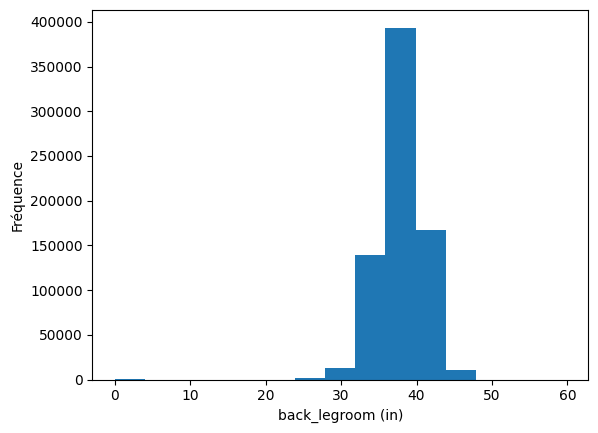

In [10]:
plt.figure()
plt.hist(df_train['back_legroom (in)'], bins=15)
plt.xlabel("back_legroom (in)")
plt.ylabel("Fréquence");

**3. 'bed_length'**

In [11]:
print(df_train['bed_length'].isna().value_counts(normalize=True))
print(df_train['bed_length'].unique())

bed_length
True     0.859469
False    0.140531
Name: proportion, dtype: float64
<StringArray>
[      nan, '67.1 in', '67.4 in', '69.9 in', '78.7 in',   '74 in', '76.3 in',
 '69.3 in', '81.9 in', '61.7 in', '78.9 in',      '--', '66.7 in', '82.2 in',
   '67 in', '60.5 in', '98.1 in', '60.3 in',   '64 in', '79.4 in',   '61 in',
 '98.3 in',   '98 in', '97.8 in', '98.2 in', '41.5 in', '78.8 in', '59.5 in',
 '73.3 in', '82.3 in', '73.7 in', '81.8 in', '63.3 in', '72.7 in', '72.8 in',
 '73.5 in', '97.6 in', '71.7 in', '67.3 in',   '60 in', '97.4 in',   '63 in',
 '82.4 in', '49.6 in',   '96 in', '98.6 in', '69.2 in', '76.1 in', '76.5 in',
 '77.4 in', '74.3 in', '73.2 in', '77.5 in', '98.5 in', '75.9 in', '78.6 in',
 '79.1 in', '72.3 in', '74.5 in',   '50 in', '64.9 in', '61.1 in', '67.2 in',
   '66 in', '71.8 in', '63.6 in',   '97 in', '61.5 in', '76.8 in', '59.3 in',
   '87 in', '63.7 in']
Length: 72, dtype: str


85% de valeurs manquantes, on ne garde pas la variale

In [12]:
df_train = df_train.drop(['bed_length'], axis =1)

**4.'body_type'**

body_type
False    0.994778
True     0.005222
Name: proportion, dtype: float64
<StringArray>
['SUV / Crossover',       'Hatchback',           'Sedan',    'Pickup Truck',
         'Minivan',     'Convertible',           'Coupe',               nan,
             'Van',           'Wagon']
Length: 10, dtype: str


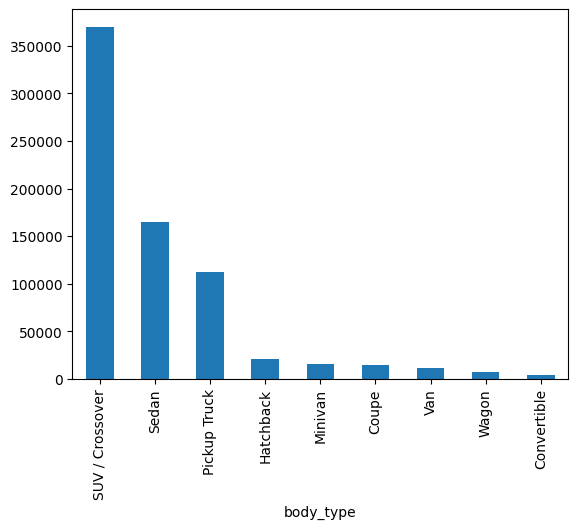

In [13]:
print(df_train['body_type'].isna().value_counts(normalize=True))
print(df_train['body_type'].unique())
df_train['body_type'].value_counts().plot.bar();

0,5% de valeurs manquantes qu'on remplace par la catégorie la plus représentée ("SUV/Crossover"), on garde les 3 catégories les plus représentées et on regroupe les autres.

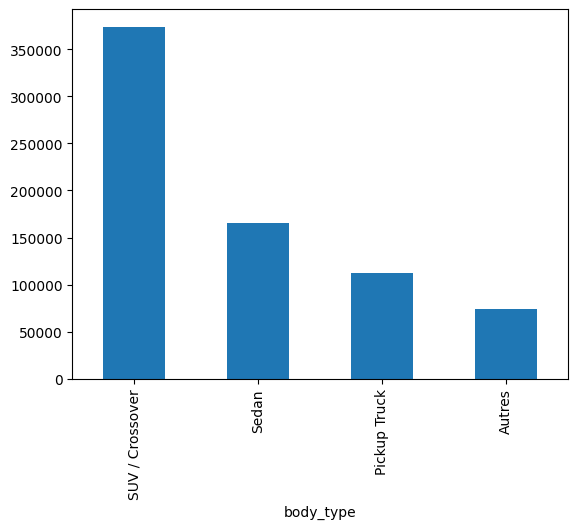

In [14]:
df_train['body_type'] = df_train['body_type'].fillna('SUV / Crossover')

categories = df_train["body_type"].value_counts().nlargest(3).index
df_train["body_type"] = df_train["body_type"].where(
    df_train["body_type"].isin(categories),
    "Autres"
)
df_train['body_type'].value_counts().plot.bar();

**5. 'city_fuel_economy'**

In [15]:
print(df_train['city_fuel_economy'].isna().value_counts(normalize=True))
print(df_train['city_fuel_economy'].describe())

city_fuel_economy
False    0.849896
True     0.150104
Name: proportion, dtype: float64
count    616793.000000
mean         23.373800
std           9.451964
min           8.000000
25%          18.000000
50%          22.000000
75%          26.000000
max         127.000000
Name: city_fuel_economy, dtype: float64


15% de valeurs manquantes, que l'on remplace par la médiane (médiane et moyenne sont proche)

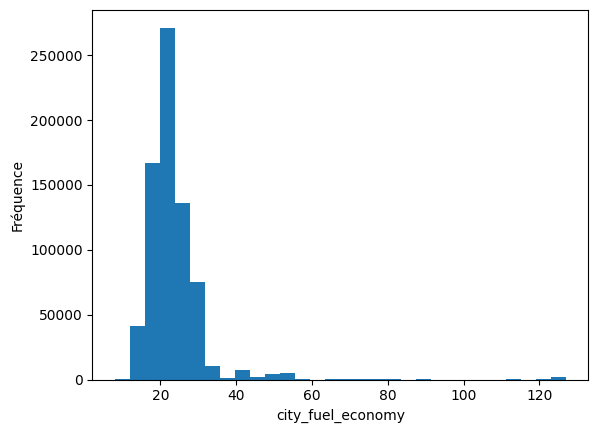

In [16]:
df_train['city_fuel_economy'] = df_train['city_fuel_economy'].fillna(22) #median

plt.figure()
plt.hist(df_train['city_fuel_economy'], bins=30)
plt.xlabel("city_fuel_economy")
plt.ylabel("Fréquence");

**6. 'combine_fuel_economy'**

La variable est vide, donc on la supprime.

In [17]:
df_train = df_train.drop(["combine_fuel_economy"], axis =1)

**7. 'daysonmarket'**

In [18]:
print(df_train['daysonmarket'].isna().value_counts(normalize=True))
print(df_train['daysonmarket'].describe())

daysonmarket
False    1.0
Name: proportion, dtype: float64
count    725728.00000
mean         76.79909
std          85.62350
min           0.00000
25%          18.00000
50%          41.00000
75%          95.00000
max         364.00000
Name: daysonmarket, dtype: float64


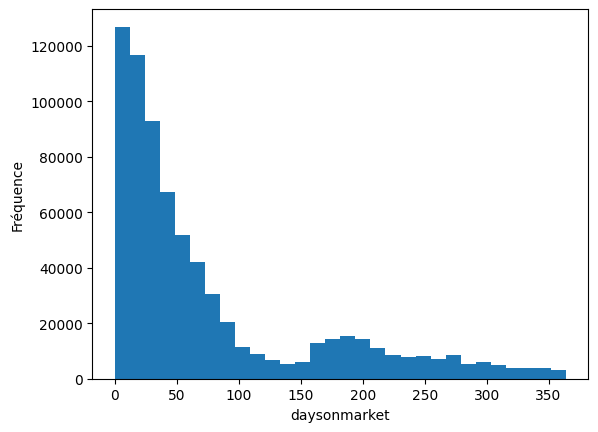

In [19]:
plt.figure()
plt.hist(df_train['daysonmarket'], bins=30)
plt.xlabel("daysonmarket")
plt.ylabel("Fréquence");

**8. 'engine_cylinders'**


engine_cylinders
False    0.968079
True     0.031921
Name: proportion, dtype: float64
<StringArray>
[                       'I4',                         nan,
                        'V6',                        'H4',
                        'V8',                        'I3',
                 'V8 Diesel',      'V8 Flex Fuel Vehicle',
                 'I4 Hybrid',      'V6 Flex Fuel Vehicle',
              'V8 Biodiesel',                        'I6',
      'I4 Flex Fuel Vehicle',                 'I6 Diesel',
                 'V6 Diesel',                 'V6 Hybrid',
              'V6 Biodiesel',                 'I4 Diesel',
                        'H6',                       'V12',
                        'I2',                       'V10',
                        'I5',                       'W12',
              'I5 Biodiesel', 'V8 Compressed Natural Gas',
                        'R2',                 'I5 Diesel',
                 'H4 Hybrid',     'W12 Flex Fuel Vehicle',
 'I4 Compressed

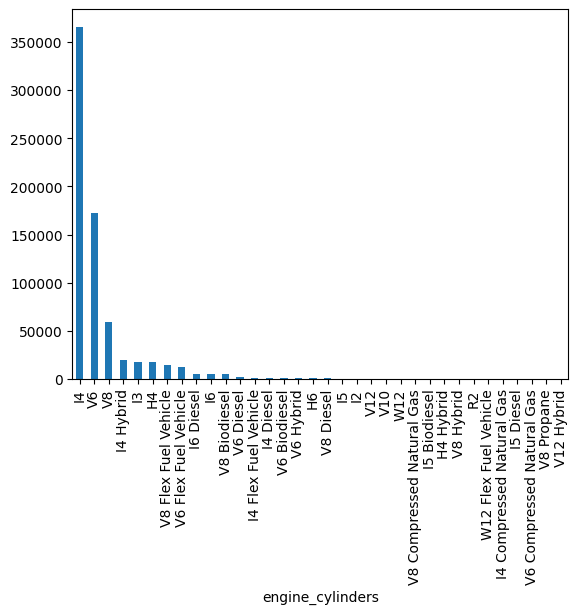

In [20]:
print(df_train['engine_cylinders'].isna().value_counts(normalize=True))
print(df_train['engine_cylinders'].unique())

df_train['engine_cylinders'].value_counts().plot.bar();

3% de valeurs manquantes que l'on remplace par la catégorie la plus représentée ("I4"). On garde les 8 catégories les plus représentées et on regroupe les autres.

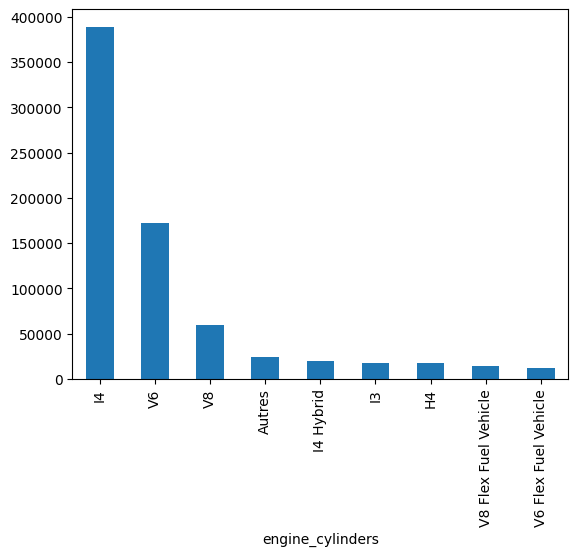

In [21]:
df_train['engine_cylinders'] = df_train['engine_cylinders'].fillna("I4")

categories = df_train["engine_cylinders"].value_counts().nlargest(8).index
df_train["engine_cylinders"] = df_train["engine_cylinders"].where(
    df_train["engine_cylinders"].isin(categories),
    "Autres"
)

df_train['engine_cylinders'].value_counts().plot.bar();

**9. 'engine_displacement'**

In [22]:
print(df_train['engine_displacement'].isna().value_counts(normalize=True))
print(df_train['engine_displacement'].describe())

engine_displacement
False    0.941591
True     0.058409
Name: proportion, dtype: float64
count    683339.000000
mean       2844.960700
std        1302.430612
min         700.000000
25%        2000.000000
50%        2500.000000
75%        3500.000000
max        8400.000000
Name: engine_displacement, dtype: float64


5% de valeurs manquantes, que l'on remplace par la médiane

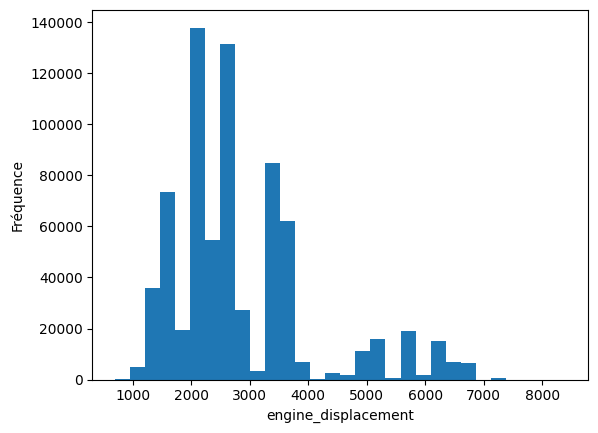

In [23]:
df_train['engine_displacement'] = df_train['engine_displacement'].fillna(2500) #median

plt.figure()
plt.hist(df_train['engine_displacement'], bins=30)
plt.xlabel("engine_displacement")
plt.ylabel("Fréquence");

**10. 'engine_type'**

engine_type
False    0.968079
True     0.031921
Name: proportion, dtype: float64
<StringArray>
[                       'I4',                         nan,
                        'V6',                        'H4',
                        'V8',                        'I3',
                 'V8 Diesel',      'V8 Flex Fuel Vehicle',
                 'I4 Hybrid',      'V6 Flex Fuel Vehicle',
              'V8 Biodiesel',                        'I6',
      'I4 Flex Fuel Vehicle',                 'I6 Diesel',
                 'V6 Diesel',                 'V6 Hybrid',
              'V6 Biodiesel',                 'I4 Diesel',
                        'H6',                       'V12',
                        'I2',                       'V10',
                        'I5',                       'W12',
              'I5 Biodiesel', 'V8 Compressed Natural Gas',
                        'R2',                 'I5 Diesel',
                 'H4 Hybrid',     'W12 Flex Fuel Vehicle',
 'I4 Compressed Natu

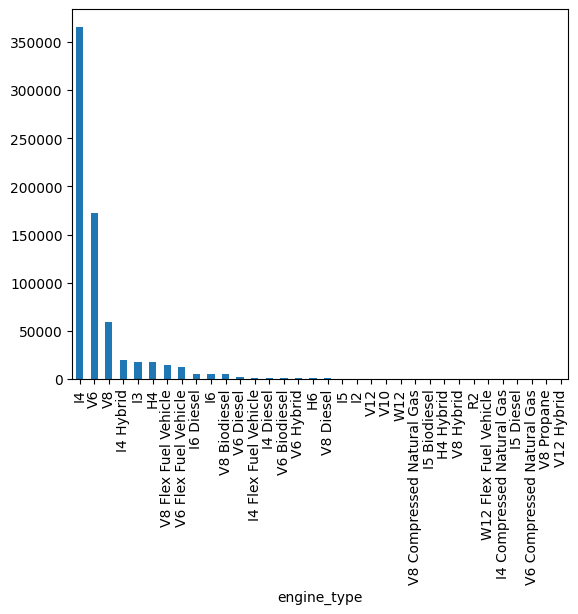

In [24]:
print(df_train['engine_type'].isna().value_counts(normalize=True))
print(df_train['engine_type'].unique())

df_train['engine_type'].value_counts().plot.bar();

Même variable que 'engine_cylinders' donc on l'enlève

In [25]:
df_train = df_train.drop(["engine_type"], axis =1)

**11. 'fleet'**

In [26]:
print(df_train['fleet'].isna().value_counts(normalize=True))
print(df_train['fleet'].unique())

fleet
True     0.627187
False    0.372813
Name: proportion, dtype: float64
[False nan True]


37% de valeurs manquantes, on préfère enlever la variable.

In [27]:
df_train = df_train.drop(["fleet"], axis =1)

**12. 'franchise_dealer'**

In [28]:
print(df_train['franchise_dealer'].isna().value_counts(normalize=True))
(df_train['franchise_dealer'] == True).value_counts(normalize=True)

franchise_dealer
False    1.0
Name: proportion, dtype: float64


franchise_dealer
True     0.912915
False    0.087085
Name: proportion, dtype: float64

**13. 'franchise_make'**

franchise_make
False    0.911563
True     0.088437
Name: proportion, dtype: float64
<StringArray>
[            nan,     'Chevrolet',        'Toyota',           'BMW',
          'Ford',       'Hyundai',      'INFINITI',      'Chrysler',
        'Subaru',       'Lincoln',           'RAM',          'Jeep',
         'Honda',        'Nissan',    'Mitsubishi',           'Kia',
         'Lexus',         'Buick',           'GMC',    'Volkswagen',
         'Mazda', 'Mercedes-Benz',        'Jaguar',         'Dodge',
    'Land Rover',         'Volvo',          'Audi',      'Cadillac',
          'MINI',       'Porsche',         'Scion',         'Acura',
          'FIAT',    'Alfa Romeo',   'Rolls-Royce',       'Genesis',
       'Ferrari',      'Maserati',  'Aston Martin',       'McLaren',
       'Bentley',  'Freightliner',         'Lotus',   'Lamborghini',
        'Shelby',         'Rover',           'SRT',         'smart',
        'Pagani']
Length: 49, dtype: str


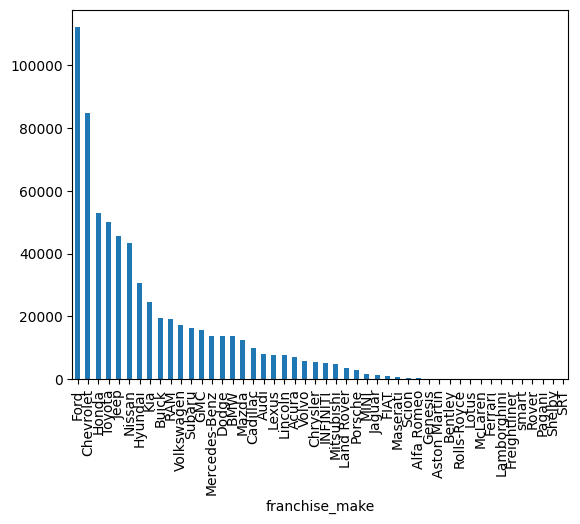

In [29]:
print(df_train['franchise_make'].isna().value_counts(normalize=True))
print(df_train['franchise_make'].unique())

df_train['franchise_make'].value_counts().plot.bar();

8% de valeurs manquantes que l'on remplace par "Ford", on garde les 25 catégories les plus représentées

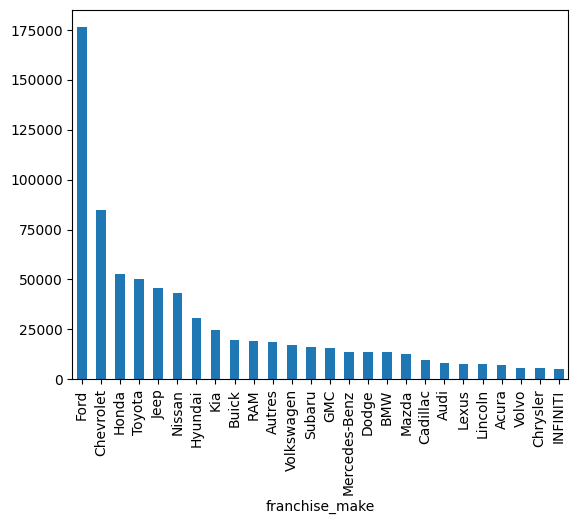

In [30]:
df_train['franchise_make'] = df_train['franchise_make'].fillna('Ford')

categories = df_train['franchise_make'].value_counts().nlargest(25).index
df_train['franchise_make'] = df_train['franchise_make'].where(
    df_train['franchise_make'].isin(categories),
    "Autres"
)

df_train['franchise_make'].value_counts().plot.bar();

**14. 'front_legroom'**

In [31]:
print(df_train['front_legroom'].isna().value_counts(normalize=True))
print(df_train['front_legroom'].unique())

(df_train['front_legroom'] == "--").value_counts(normalize=True)

front_legroom
False    0.94892
True     0.05108
Name: proportion, dtype: float64
<StringArray>
['40.9 in',       nan, '40.8 in',   '41 in', '42.1 in', '40.3 in', '43.9 in',
 '41.8 in', '44.5 in', '41.1 in', '42.8 in', '43.2 in', '42.6 in', '45.3 in',
 '41.5 in', '41.2 in', '42.9 in', '42.2 in', '42.3 in',   '43 in', '41.4 in',
   '45 in', '42.4 in', '41.3 in', '43.6 in', '41.9 in', '40.5 in', '41.7 in',
 '45.5 in', '44.1 in', '43.3 in', '44.3 in', '43.1 in', '40.2 in', '39.6 in',
   '42 in', '39.1 in', '43.7 in', '44.2 in', '42.5 in', '43.5 in',   '40 in',
 '45.7 in', '40.4 in', '44.4 in', '41.6 in',      '--', '43.8 in', '40.1 in',
 '38.9 in', '40.7 in', '40.6 in',   '44 in', '38.8 in', '45.8 in', '45.1 in',
 '39.8 in', '46.3 in', '53.6 in', '46.1 in', '42.7 in', '37.7 in', '39.9 in',
 '39.5 in', '43.4 in',   '39 in', '46.4 in', '36.6 in', '45.4 in', '44.8 in',
   '67 in', '44.7 in', '46.9 in', '38.7 in', '35.8 in', '52.5 in', '44.6 in',
 '39.4 in',   '38 in',   '33 in', '45.9 in', '3

front_legroom
False    0.994413
True     0.005587
Name: proportion, dtype: float64

5% de valeurs manquantes que l'on remplace par la moyenne, même traitement que 'back_legroom'

In [32]:
df_train['front_legroom (in)'] = (
    df_train['front_legroom']
    .str.replace(" in", "", regex=False)
    .replace("--", np.nan , regex=False)
    .astype(float)
)
df_train = df_train.drop(["front_legroom"], axis =1)
df_train['front_legroom (in)'].describe()

count    684603.000000
mean         42.197135
std           1.499917
min          29.000000
25%          41.000000
50%          42.000000
75%          43.000000
max          67.000000
Name: front_legroom (in), dtype: float64

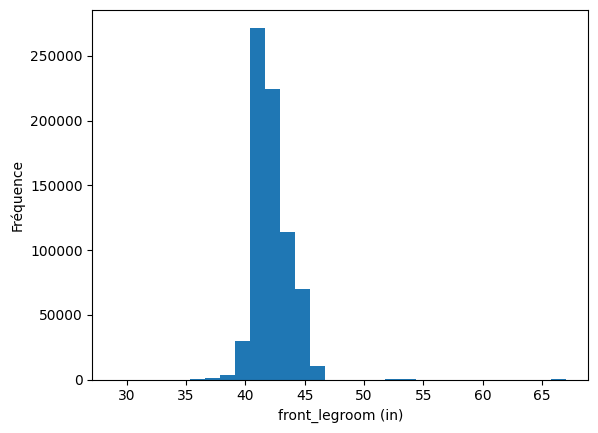

In [33]:
df_train['front_legroom (in)'] = df_train['front_legroom (in)'].fillna(42.19) #mean

plt.figure()
plt.hist(df_train['front_legroom (in)'], bins=30)
plt.xlabel("front_legroom (in)")
plt.ylabel("Fréquence");

**15. 'fuel_tank_volume'**

In [34]:
print(df_train['fuel_tank_volume'].isna().value_counts(normalize=True))
print(df_train['fuel_tank_volume'].unique())

(df_train['fuel_tank_volume'] == "--").value_counts(normalize=True)

fuel_tank_volume
False    0.94892
True     0.05108
Name: proportion, dtype: float64
<StringArray>
['15.6 gal',        nan,   '14 gal', '14.5 gal',   '16 gal', '17.2 gal',
   '26 gal', '11.4 gal',   '20 gal',   '19 gal',
 ...
   '42 gal',  '1.9 gal',  '8.5 gal', '20.2 gal', '15.2 gal',   '50 gal',
   '10 gal', '16.7 gal', '13.3 gal', '18.7 gal']
Length: 168, dtype: str


fuel_tank_volume
False    0.999684
True     0.000316
Name: proportion, dtype: float64

5% de valeurs manquantes que l'on remplace par la moyenne, même traitement que 'back_legroom'

In [35]:
df_train['fuel_tank_volume (gal)'] = (
    df_train['fuel_tank_volume']
    .str.replace(" gal", "", regex=False)
    .replace("--", np.nan , regex=False)
    .astype(float)
)
df_train = df_train.drop(["fuel_tank_volume"], axis =1)
df_train['fuel_tank_volume (gal)'].describe()

count    688429.000000
mean         18.260594
std           5.295396
min           1.900000
25%          14.500000
50%          17.100000
75%          21.000000
max          64.000000
Name: fuel_tank_volume (gal), dtype: float64

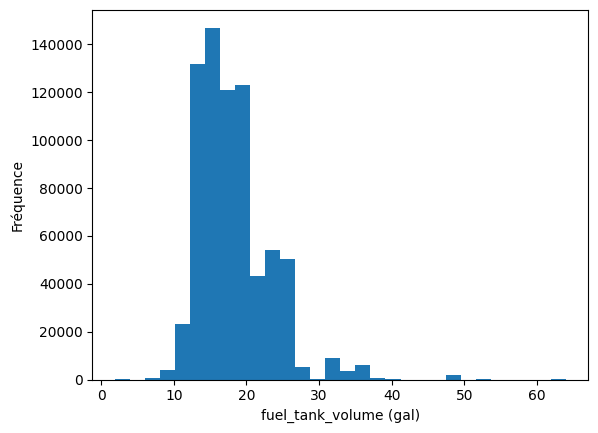

In [36]:
df_train['fuel_tank_volume (gal)'] = df_train['fuel_tank_volume (gal)'].fillna(18.26) #mean

plt.figure()
plt.hist(df_train['fuel_tank_volume (gal)'], bins=30)
plt.xlabel("fuel_tank_volume (gal)")
plt.ylabel("Fréquence");

**16. 'fuel_type'**

fuel_type
False    0.975624
True     0.024376
Name: proportion, dtype: float64
<StringArray>
[              'Gasoline',               'Electric',                 'Diesel',
                      nan,      'Flex Fuel Vehicle',                 'Hybrid',
              'Biodiesel', 'Compressed Natural Gas',                'Propane']
Length: 9, dtype: str


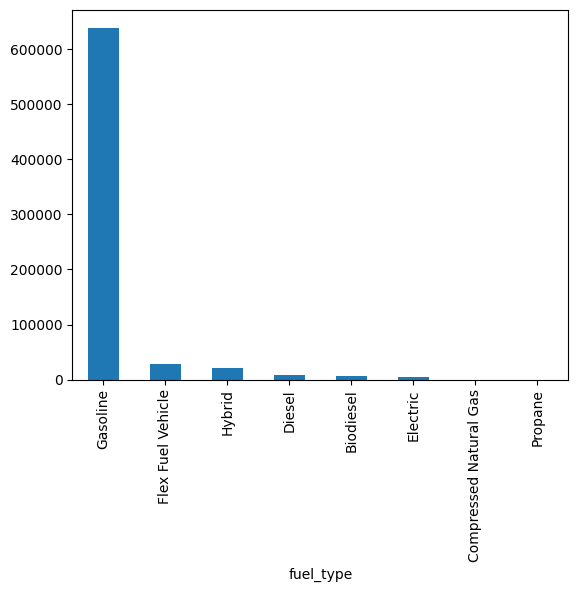

In [37]:
print(df_train['fuel_type'].isna().value_counts(normalize=True))
print(df_train['fuel_type'].unique())

df_train['fuel_type'].value_counts().plot.bar();


2% de valeurs manquantes que l'on remplace par "Gasoline". On garde les 3 catégories les plus représentées

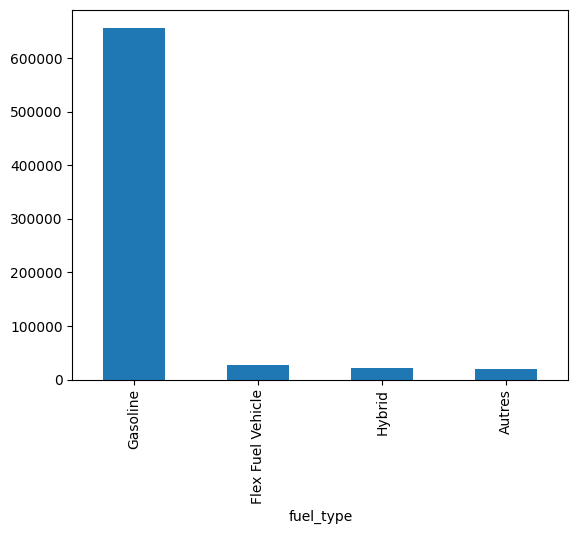

In [38]:
df_train['fuel_type'] = df_train['fuel_type'].fillna("Gasoline")

categories = df_train['fuel_type'].value_counts().nlargest(3).index
df_train['fuel_type'] = df_train['fuel_type'].where(
    df_train['fuel_type'].isin(categories),
    "Autres"
)

df_train['fuel_type'].value_counts().plot.bar();

**17. 'height'**

In [39]:
print(df_train['height'].isna().value_counts(normalize=True))
print(df_train['height'].unique())

(df_train['height'] == "--").value_counts(normalize=True)

height
False    0.94892
True     0.05108
Name: proportion, dtype: float64
<StringArray>
[ '65.4 in',        nan,    '66 in',    '67 in',  '56.9 in',  '77.2 in',
  '57.1 in',  '57.2 in',  '69.9 in',  '59.1 in',
 ...
 '108.8 in',  '52.5 in',    '44 in',  '82.8 in',  '81.8 in',  '48.3 in',
 '110.6 in', '105.8 in',  '43.9 in',  '46.8 in']
Length: 442, dtype: str


height
False    0.999865
True     0.000135
Name: proportion, dtype: float64

5% de valeurs manquantes que l'on remplace par la moyenne. Même traitement que "back_legroom"

In [40]:
df_train['height (in)'] = (
    df_train['height']
    .str.replace(" in", "", regex=False)
    .replace("--", np.nan , regex=False)
    .astype(float)
)
df_train = df_train.drop(["height"], axis =1)
df_train['height (in)'].describe()

count    688560.000000
mean         65.993890
std           7.392038
min          43.900000
25%          58.200000
50%          66.100000
75%          70.000000
max         117.600000
Name: height (in), dtype: float64

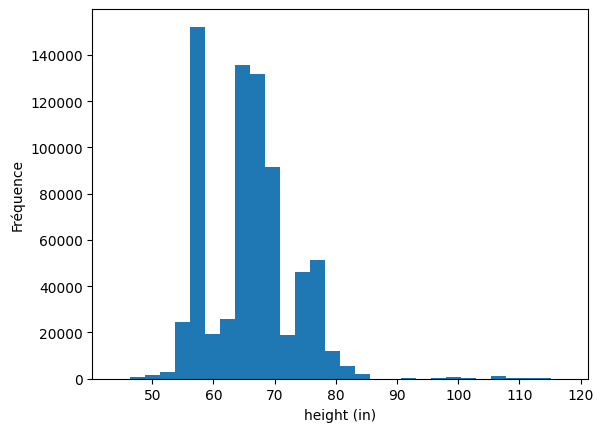

In [41]:
df_train['height (in)'] = df_train['height (in)'].fillna(66) #mean

plt.figure()
plt.hist(df_train['height (in)'], bins=30)
plt.xlabel("height (in)")
plt.ylabel("Fréquence");

**18. 'highway_fuel_economy'**

In [42]:
print(df_train['highway_fuel_economy'].isna().value_counts(normalize=True))
print(df_train['highway_fuel_economy'].describe())

highway_fuel_economy
False    0.849896
True     0.150104
Name: proportion, dtype: float64
count    616793.000000
mean         29.972177
std           8.079755
min          11.000000
25%          25.000000
50%          29.000000
75%          33.000000
max         127.000000
Name: highway_fuel_economy, dtype: float64


15% de valeurs manquantes que l'on remplace par la médiane

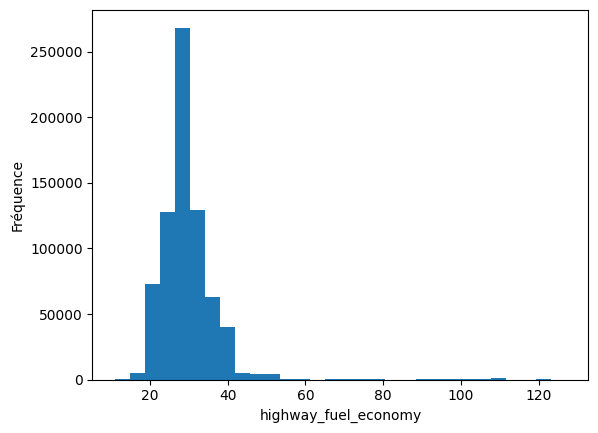

In [43]:
df_train['highway_fuel_economy'] = df_train['highway_fuel_economy'].fillna(29) #median

plt.figure()
plt.hist(df_train['highway_fuel_economy'], bins=30)
plt.xlabel("highway_fuel_economy")
plt.ylabel("Fréquence");

**19. 'horsepower'**

In [44]:
print(df_train['horsepower'].isna().value_counts(normalize=True))
print(df_train['horsepower'].describe())

horsepower
False    0.941591
True     0.058409
Name: proportion, dtype: float64
count    683339.000000
mean        246.167552
std          90.825499
min          55.000000
25%         174.000000
50%         240.000000
75%         300.000000
max         949.000000
Name: horsepower, dtype: float64


5% de valeurs manquantes que l'on remplace par la médiane

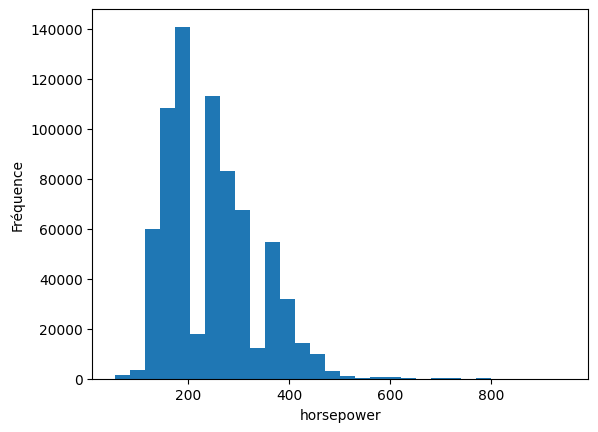

In [45]:
df_train['horsepower'] = df_train['horsepower'].fillna(240) #median

plt.figure()
plt.hist(df_train['horsepower'], bins=30)
plt.xlabel("horsepower")
plt.ylabel("Fréquence");

**20. 'is_new'**

In [46]:
print(df_train['is_new'].isna().value_counts(normalize=True))
(df_train['is_new'] == True).value_counts(normalize=True)

is_new
False    1.0
Name: proportion, dtype: float64


is_new
True     0.646684
False    0.353316
Name: proportion, dtype: float64

**21. 'is_oemcpo'**

In [47]:
print(df_train['is_oemcpo'].isna().value_counts(normalize=True))
(df_train['is_oemcpo'] == True).value_counts(normalize=True)

is_oemcpo
True     0.949611
False    0.050389
Name: proportion, dtype: float64


is_oemcpo
False    0.949611
True     0.050389
Name: proportion, dtype: float64

Trop de valeurs manquantes, on ne garde pas la variable

In [48]:
df_train = df_train.drop(['is_oemcpo'], axis =1)

**22. 'length'**

In [49]:
print(df_train['length'].isna().value_counts(normalize=True))
print(df_train['length'].unique())

(df_train['length'] == "--").value_counts(normalize=True)

length
False    0.94892
True     0.05108
Name: proportion, dtype: float64
<StringArray>
['182.3 in',        nan, '167.6 in', '180.9 in', '192.1 in', '185.9 in',
 '231.9 in',   '172 in', '189.6 in', '204.3 in',
 ...
 '167.8 in', '258.5 in', '221.7 in',   '262 in', '156.1 in', '206.4 in',
 '247.6 in', '175.7 in', '165.1 in', '204.2 in']
Length: 741, dtype: str


length
False    0.999866
True     0.000134
Name: proportion, dtype: float64

5% de valeurs manquantes que l'on remplace par la moyenne, même traitement que "back_legroom"

In [50]:
df_train['length (in)'] = (
    df_train['length']
    .str.replace(" in", "", regex=False)
    .replace("--", np.nan, regex=False)
    .astype(float)
)
df_train = df_train.drop(["length"], axis=1)
df_train['length (in)'].describe()

count    688561.000000
mean        193.074601
std          20.163539
min         106.100000
25%         181.900000
50%         189.800000
75%         198.800000
max         290.000000
Name: length (in), dtype: float64

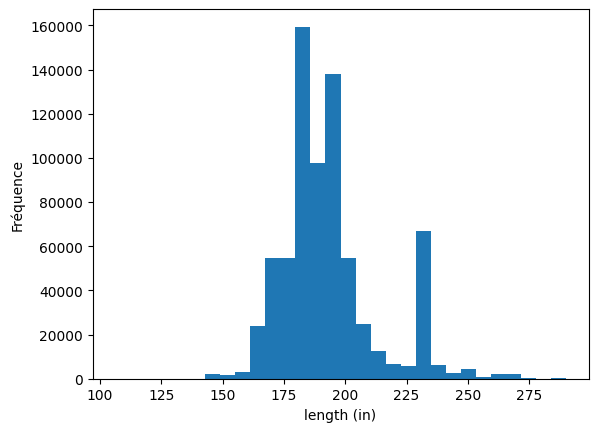

In [51]:
df_train['length (in)'] = df_train['length (in)'].fillna(193.07) #mean

plt.figure()
plt.hist(df_train['length (in)'], bins=30)
plt.xlabel("length (in)")
plt.ylabel("Fréquence");

**23. 'listed_date'**

In [52]:
print(df_train['listed_date'].isna().value_counts(normalize=True))
print(df_train['listed_date'].unique())

listed_date
False    1.0
Name: proportion, dtype: float64
<StringArray>
['2020-07-30', '2020-08-23', '2020-07-18', '2020-07-10', '2020-09-10',
 '2020-08-30', '2020-09-01', '2020-09-03', '2020-06-30', '2020-08-13',
 ...
 '2020-04-13', '2019-10-15', '2020-04-27', '2019-09-23', '2020-01-27',
 '2019-09-24', '2019-10-14', '2019-09-11', '2019-10-21', '2020-09-13']
Length: 369, dtype: str


On décide de ne pas prendre en compte cette variable, car on cosidère la variable "year" plus adaptée

In [53]:
df_train = df_train.drop(['listed_date'], axis=1)

**24. 'listing_color'**

listing_color
False    1.0
Name: proportion, dtype: float64
<StringArray>
[   'GRAY',    'BLUE',   'BLACK', 'UNKNOWN',   'WHITE',  'SILVER',   'GREEN',
     'RED',   'BROWN',  'ORANGE',    'GOLD',    'TEAL',  'YELLOW',  'PURPLE',
    'PINK']
Length: 15, dtype: str


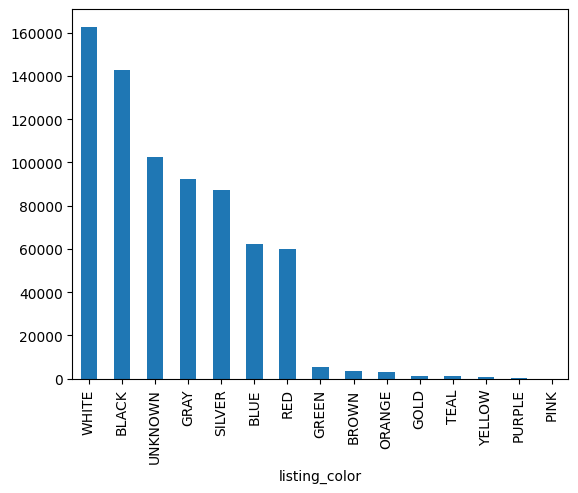

In [54]:
print(df_train['listing_color'].isna().value_counts(normalize=True))
print(df_train['listing_color'].unique())

df_train['listing_color'].value_counts().plot.bar();


On garde les 7 catégories les plus représentées

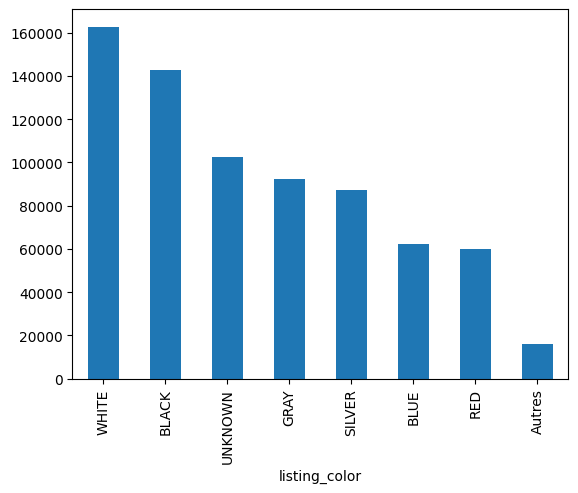

In [55]:
categories = df_train['listing_color'].value_counts().nlargest(7).index
df_train['listing_color'] = df_train['listing_color'].where(
    df_train['listing_color'].isin(categories),
    "Autres"
)

df_train['listing_color'].value_counts().plot.bar();

**25. 'listing_id'**

In [56]:
print(df_train['listing_id'].isna().value_counts(normalize=True))
print(df_train['listing_id'].nunique())

listing_id
False    1.0
Name: proportion, dtype: float64
725728


c'est un id, donc on l'enlève de la base de données

In [57]:
df_train = df_train.drop(['listing_id'], axis=1)

**26. 'major_options'**

In [58]:
print(df_train['major_options'].isna().value_counts(normalize=True))
print(df_train['major_options'].unique())

major_options
False    0.938498
True     0.061502
Name: proportion, dtype: float64
<StringArray>
['['Leather Seats', 'Power Package', 'Navigation System', 'Adaptive Cruise Control', 'Alloy Wheels', 'Preferred Package', 'Trailer Package', 'Blind Spot Monitoring', 'Parking Sensors', 'Heated Seats', 'Android Auto', 'CarPlay', 'Multi Zone Climate Control', 'Bluetooth', 'Memory Package', 'Backup Camera', 'SLT Package', 'Remote Start']',
                                                                                                '['Driver Confidence Package', 'Navigation System', 'Alloy Wheels', 'Blind Spot Monitoring', 'Parking Sensors', 'Android Auto', 'CarPlay', 'SE Package', 'Bluetooth', 'Backup Camera', 'Remote Start', 'Comfort Package', 'Convenience Package']',
                                                                                                                                                                                                                               '[

On décide de supprimer la variable car il a trop de catégories différentes qu'on peut pas rassembler ensemble pour pouvoir l'exploité

In [59]:
df_train = df_train.drop(['major_options'],axis=1)

**27. 'make_name'**

make_name
False    1.0
Name: proportion, dtype: float64
<StringArray>
[                    'GMC',               'Chevrolet',
                  'Toyota',                     'BMW',
                    'Ford',                 'Hyundai',
                'INFINITI',                'Chrysler',
                  'Subaru',                 'Lincoln',
                     'RAM',                'Cadillac',
                    'Jeep',                   'Honda',
                  'Nissan',              'Mitsubishi',
                   'Dodge',                     'Kia',
                   'Lexus',              'Volkswagen',
                   'Buick',                   'Mazda',
           'Mercedes-Benz',                  'Jaguar',
                   'Acura',              'Land Rover',
                   'Volvo',                    'Audi',
                 'Genesis',                    'MINI',
              'Alfa Romeo',                 'Porsche',
                    'FIAT',                   'Tes

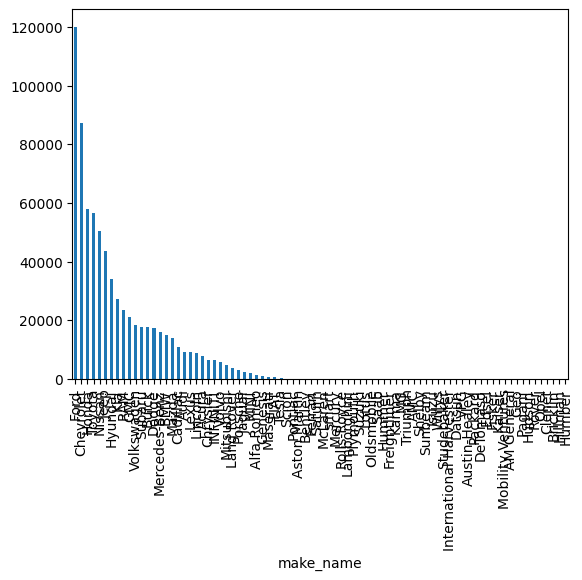

In [60]:
print(df_train['make_name'].isna().value_counts(normalize=True))
print(df_train['make_name'].unique())

df_train['make_name'].value_counts().plot.bar();


On a deja le nom de la franchise donc on peut enelver cette variable

In [61]:
df_train = df_train.drop(['make_name'], axis=1)

**28. 'maximum_seating'**

In [62]:
print(df_train['maximum_seating'].isna().value_counts(normalize=True))
print(df_train['maximum_seating'].unique())
(df_train['maximum_seating'] == "--").value_counts(normalize=True)


maximum_seating
False    0.94892
True     0.05108
Name: proportion, dtype: float64
<StringArray>
[ '5 seats',        nan,  '6 seats',  '8 seats',  '9 seats',  '7 seats',
  '4 seats',  '2 seats',  '3 seats', '15 seats', '12 seats',       '--',
 '10 seats']
Length: 13, dtype: str


maximum_seating
False    0.999857
True     0.000143
Name: proportion, dtype: float64

5% de valeurs manquantes que l'on remplace par la médiane, même traitement que "front_legroom"

In [63]:
df_train['maximum_seating'] = (
    df_train['maximum_seating']
    .str.replace(" seats", "", regex=False)
    .replace("--", np.nan, regex=False)
    .astype(float)
)
df_train['maximum_seating'].describe()

count    688554.000000
mean          5.451167
std           1.102412
min           2.000000
25%           5.000000
50%           5.000000
75%           6.000000
max          15.000000
Name: maximum_seating, dtype: float64

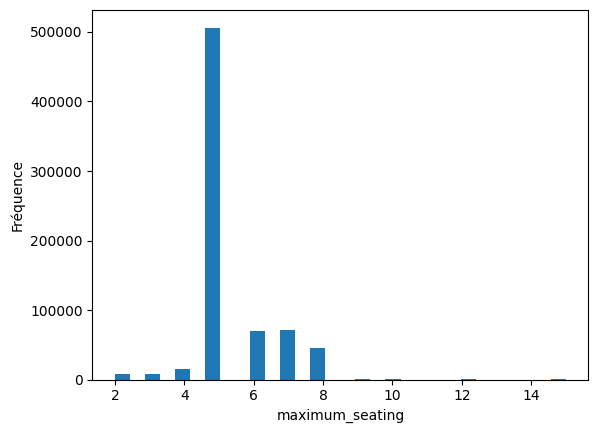

In [64]:
df_train['maximum_seating'] = df_train['maximum_seating'].fillna(5) #median

plt.figure()
plt.hist(df_train['maximum_seating'], bins=30)
plt.xlabel("maximum_seating")
plt.ylabel("Fréquence");

**29. 'mileage'**

In [65]:
print(df_train['mileage'].isna().value_counts(normalize=True))
print(df_train['mileage'].describe())

mileage
False    0.949256
True     0.050744
Name: proportion, dtype: float64
count    6.889020e+05
mean     1.507587e+04
std      2.903739e+04
min      0.000000e+00
25%      5.000000e+00
50%      1.200000e+01
75%      2.215000e+04
max      1.111111e+06
Name: mileage, dtype: float64


5% de valeurs manquantes que l'on remplace par la moyenne

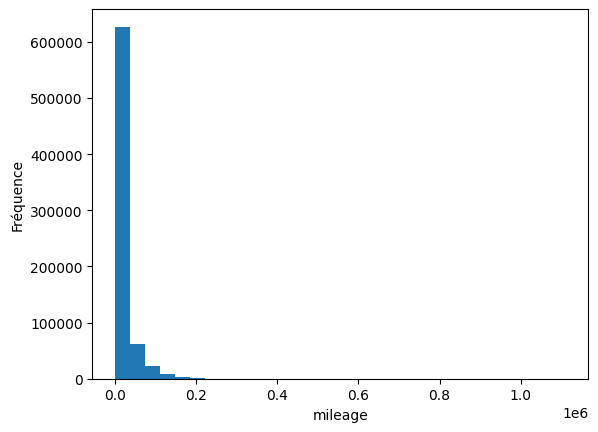

In [66]:
df_train['mileage'] = df_train['mileage'].fillna(15075.83) #mean

plt.figure()
plt.hist(df_train['mileage'], bins=30)
plt.xlabel("mileage")
plt.ylabel("Fréquence");

**30. 'model_name'**

In [67]:
print(df_train['model_name'].isna().value_counts(normalize=True))
print(df_train['model_name'].unique())

model_name
False    1.0
Name: proportion, dtype: float64
<StringArray>
[       'Terrain',        'Bolt EV',           'Trax',           'RAV4',
          'Camry',             'X3',          'F-150',         'Accent',
            'Q50',       'Pacifica',
 ...
       'Millenia',         'SC 400',             'CL',         'Delray',
 '9-5 SportCombi',    'Super Snipe',      'Celebrity',            'XLR',
       'Cressida',   'MGB Roadster']
Length: 1101, dtype: str


Pareil, comme on a la franchise, on enlève cette variable

In [68]:
df_train = df_train.drop(['model_name'], axis=1)

**31. 'power'**

In [69]:
print(df_train['power'].isna().value_counts(normalize=True))
print(df_train['power'].unique())

power
False    0.820234
True     0.179766
Name: proportion, dtype: float64
<StringArray>
['252 hp @ 5,500 RPM',                  nan, '138 hp @ 4,900 RPM',
 '248 hp @ 5,200 RPM', '395 hp @ 5,750 RPM', '137 hp @ 6,300 RPM',
 '300 hp @ 6,400 RPM', '287 hp @ 6,400 RPM', '182 hp @ 5,800 RPM',
 '250 hp @ 5,500 RPM',
 ...
 '164 hp @ 6,400 RPM', '343 hp @ 7,400 RPM', '444 hp @ 7,400 RPM',
 '903 hp @ 7,300 RPM', '214 hp @ 5,800 RPM', '355 hp @ 5,300 RPM',
 '240 hp @ 8,300 RPM', '155 hp @ 5,000 RPM', '258 hp @ 6,250 RPM',
 '205 hp @ 4,200 RPM']
Length: 1473, dtype: str


17% de valeurs manquantes que l'on remplace par la moyenne. On a déjà l'info pour "hp" (horsepower) dans une autre variable donc on garde que "RPM".

In [70]:
df_train['power (RPM)'] = (
    df_train['power']
    .str.split("@").str[1]
    .str.replace(" RPM", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace("'", "", regex=False)
    .astype(float)
    )
df_train['power (RPM)'].describe()

count    595267.000000
mean       5761.105138
std         714.892056
min         516.000000
25%        5500.000000
50%        5800.000000
75%        6200.000000
max        9000.000000
Name: power (RPM), dtype: float64

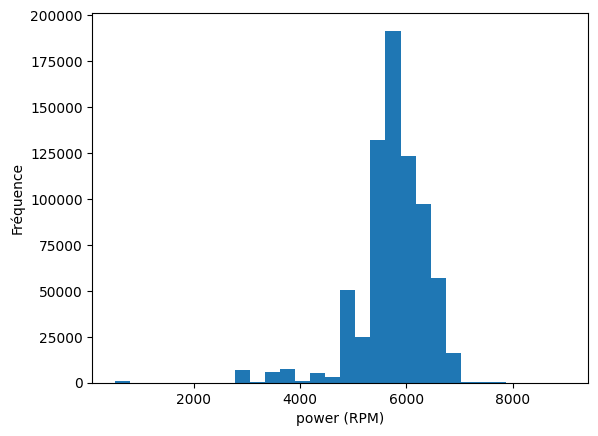

In [71]:
df_train['power (RPM)'] = df_train['power (RPM)'].fillna(5761.10) #mean
df_train = df_train.drop(["power"], axis =1)

plt.figure()
plt.hist(df_train['power (RPM)'], bins=30)
plt.xlabel("power (RPM)")
plt.ylabel("Fréquence");

**32. 'price'**

In [72]:
print(df_train['price'].isna().value_counts(normalize=True))
print(df_train['price'].describe())

price
False    1.0
Name: proportion, dtype: float64
count    7.257280e+05
mean     3.325187e+04
std      1.925604e+04
min      7.000000e+02
25%      2.198800e+04
50%      2.911200e+04
75%      4.090800e+04
max      2.749950e+06
Name: price, dtype: float64


**33. 'sp_name'**

In [73]:
print(df_train['sp_name'].isna().value_counts(normalize=True))
print(df_train['sp_name'].unique())

sp_name
False    1.0
Name: proportion, dtype: float64
<StringArray>
[              'Denney Motor Sales Inc',
 'Lithia Chevrolet Buick GMC of Helena',
             'Galles Chevrolet Company',
             'Pinehurst Toyota-Hyundai',
                      'Avondale Toyota',
           'Sandy Sansing BMW and MINI',
                'Mike Brown Auto Group',
                 'Lester Glenn Hyundai',
          'Crossroads INFINITI of Apex',
     'Champion Chrysler Jeep Dodge Ram',
 ...
                      'Easy Auto Sales',
                     'Belts Auto Sales',
                'Mt. Morris Auto Sales',
                  'Wolfe Brothers Auto',
                           'Final Auto',
                 'Premier Motor Sports',
                  'Sabattus Auto Sales',
                     'B & J Auto Sales',
                  'Your Affordable Car',
                     'Brookside Motors']
Length: 21813, dtype: str


Pareil, on enlève cette variable, on a déjà le nom de la franchise.

In [74]:
df_train = df_train.drop(['sp_name'], axis=1)

**34. 'torque'**

In [75]:
print(df_train['torque'].isna().value_counts(normalize=True))
print(df_train['torque'].unique())

torque
False    0.809163
True     0.190837
Name: proportion, dtype: float64
<StringArray>
['260 lb-ft @ 2,000 RPM',                     nan,   '148 lb-ft @ 200 RPM',
 '258 lb-ft @ 1,450 RPM', '400 lb-ft @ 4,500 RPM', '123 lb-ft @ 4,850 RPM',
 '295 lb-ft @ 1,600 RPM', '262 lb-ft @ 4,000 RPM', '176 lb-ft @ 4,400 RPM',
 '275 lb-ft @ 3,000 RPM',
 ...
 '380 lb-ft @ 4,500 RPM', '664 lb-ft @ 4,000 RPM', '221 lb-ft @ 2,800 RPM',
 '384 lb-ft @ 4,400 RPM', '153 lb-ft @ 7,500 RPM', '325 lb-ft @ 4,400 RPM',
 '395 lb-ft @ 4,000 RPM', '210 lb-ft @ 3,500 RPM', '290 lb-ft @ 2,800 RPM',
 '188 lb-ft @ 3,600 RPM']
Length: 1449, dtype: str


presque 20% de valeurs manquantes par la médiane, on remarque que ce "RPM" est différent du précédent donc on le garde, et on divise cette variable en 2.

In [76]:
df_train['torque (RPM)'] = (
    df_train['torque']
    .str.split("@").str[1]
    .str.replace(" RPM", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace("'", "", regex=False)
    .astype(float)
)
print(df_train['torque (RPM)'].describe())

df_train['torque (lb-ft)'] = (
    df_train['torque']
    .str.split("@").str[0]
    .str.replace(" lb-ft", "", regex=False)
    .astype(float)
)
print(df_train['torque (lb-ft)'].describe())

count    587232.000000
mean       3404.499414
std        1307.410805
min         200.000000
25%        2000.000000
50%        4000.000000
75%        4400.000000
max        7500.000000
Name: torque (RPM), dtype: float64
count    587232.000000
mean        263.052535
std         118.046560
min          58.000000
25%         176.000000
50%         258.000000
75%         306.000000
max         944.000000
Name: torque (lb-ft), dtype: float64


In [77]:
df_train['torque (RPM)'] = df_train['torque (RPM)'].fillna(4000) #median
df_train['torque (lb-ft)'] = df_train['torque (lb-ft)'].fillna(258) #median
df_train = df_train.drop(["torque"], axis =1)

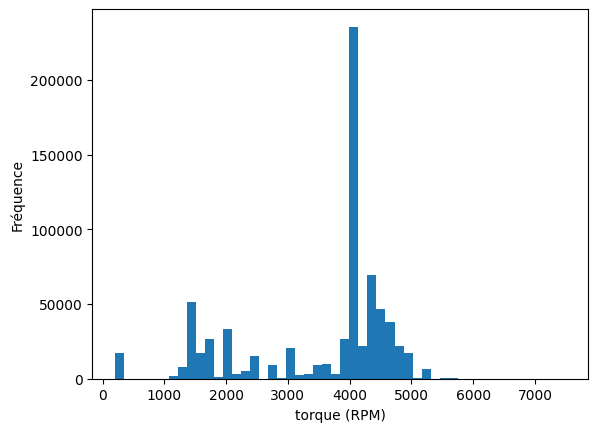

In [78]:
plt.figure()
plt.hist(df_train['torque (RPM)'], bins=50)
plt.xlabel("torque (RPM)")
plt.ylabel("Fréquence");

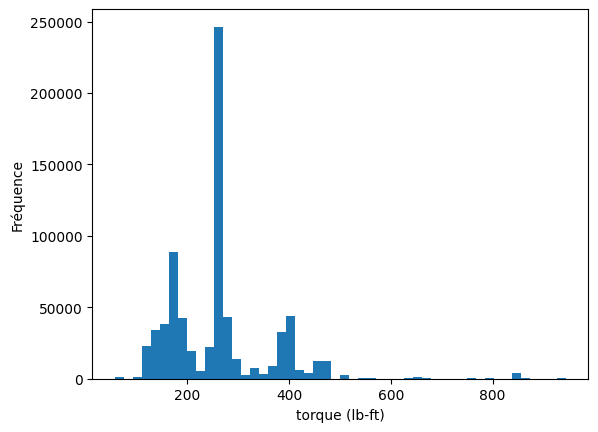

In [79]:
plt.figure()
plt.hist(df_train['torque (lb-ft)'], bins=50)
plt.xlabel("torque (lb-ft)")
plt.ylabel("Fréquence");

**35. 'transmission'**

transmission
False    0.980664
True     0.019336
Name: proportion, dtype: float64
<StringArray>
['A', nan, 'CVT', 'M', 'Dual Clutch']
Length: 5, dtype: str


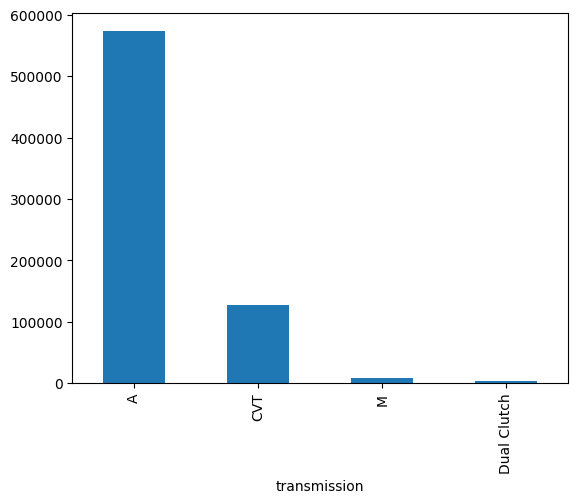

In [80]:
print(df_train['transmission'].isna().value_counts(normalize=True))
print(df_train['transmission'].unique())

df_train['transmission'].value_counts().plot.bar();

1% de valeurs manquantes que l'on remplace par "A"

In [81]:
df_train['transmission'] = df_train['transmission'].fillna("A")

**36. 'transmission_display'**

transmission_display
False    0.980664
True     0.019336
Name: proportion, dtype: float64
36


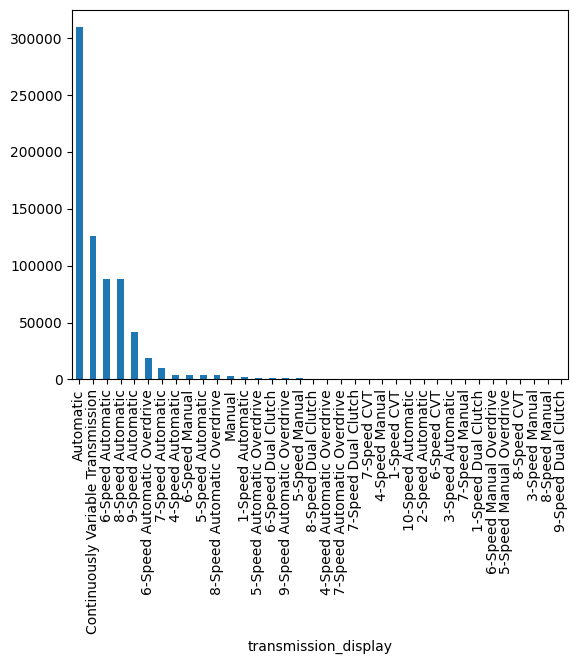

In [82]:
print(df_train['transmission_display'].isna().value_counts(normalize=True))
print(df_train['transmission_display'].nunique())

df_train['transmission_display'].value_counts().plot.bar();

On sait déjà grâce à la variable d'avant le type de transmision

In [83]:
df_train = df_train.drop(['transmission_display'], axis=1)

**37. 'trimId'**

In [84]:
print(df_train['trimId'].isna().value_counts(normalize=True))
print(df_train['trimId'].unique())

trimId
False    0.962231
True     0.037769
Name: proportion, dtype: float64
<StringArray>
['t85776', 't70554', 't85772', 't89228', 't88878', 't78157', 't87733',
 't69393', 't83646', 't87153',
 ...
 't85704', 't87552', 't67711', 't31116',  't7535',  't1598', 't57276',
 't67813', 't59803', 't57506']
Length: 21781, dtype: str


C'est un ID, on en peut pas la traiter comme une variable continues, et trop de catégories qu'on ne peut pas rassembler entre elles

In [85]:
df_train = df_train.drop(['trimId'], axis=1)

**38. 'trim_name'**

In [86]:
print(df_train['trim_name'].isna().value_counts(normalize=True))
print(df_train['trim_name'].unique())
df_train = df_train.drop(['trim_name'], axis=1)

trim_name
False    0.962183
True     0.037817
Name: proportion, dtype: float64
<StringArray>
[                             'SLT AWD',
                               'LT FWD',
                               'LE FWD',
                        'sDrive30i RWD',
                     'XL SuperCrew 4WD',
                         'SE Sedan FWD',
                       '3.0t Sport AWD',
                          'Limited FWD',
                     '2.5i Limited AWD',
                                  'FWD',
 ...
          'T5 R-Design 5-Passenger AWD',
 '150 RWD with Dual Sliding Side Doors',
            '2.0 TDI Premium Wagon FWD',
                        'LT LB DRW 4WD',
            'SR5 4dr Access Cab 4WD SB',
                'quattro Cabriolet AWD',
                         'EL SSV Fleet',
                       '228i Coupe RWD',
         '2.0T SEL Premium 4Motion AWD',
                            '2500 HD S']
Length: 5334, dtype: str


Pareil, trop de catégories qu'on ne peut pas rassembler

**39. 'wheel_system'**

wheel_system
False    0.950856
True     0.049144
Name: proportion, dtype: float64
<StringArray>
['4WD', 'FWD', 'RWD', 'AWD', nan, '4X2']
Length: 6, dtype: str


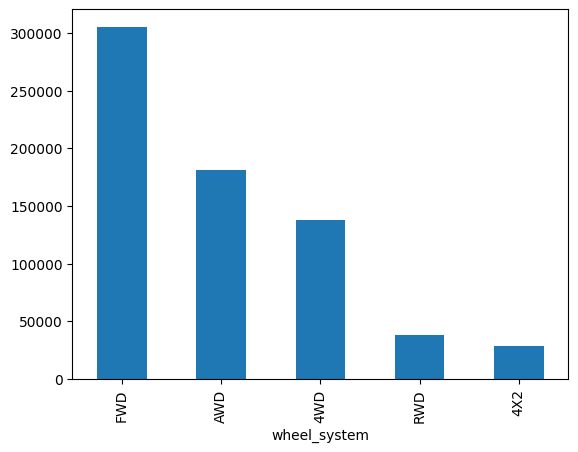

In [87]:
print(df_train['wheel_system'].isna().value_counts(normalize=True))
print(df_train['wheel_system'].unique())

df_train['wheel_system'].value_counts().plot.bar();


5% de valeurs manquantes que l'on remplace par "FWD"

In [88]:
df_train['wheel_system'] = df_train['wheel_system'].fillna("FWD")

**40. 'wheel_system_display'**

In [89]:
print(df_train['wheel_system_display'].isna().value_counts(normalize=True))
print(df_train['wheel_system_display'].unique())

wheel_system_display
False    0.950856
True     0.049144
Name: proportion, dtype: float64
<StringArray>
[ 'Four-Wheel Drive', 'Front-Wheel Drive',  'Rear-Wheel Drive',
   'All-Wheel Drive',                 nan,               '4X2']
Length: 6, dtype: str


même chose que la var précédente, donc on enlève le doublon

In [90]:
df_train = df_train.drop(['wheel_system_display'], axis=1)

**41. 'wheelbase'**

In [91]:
print(df_train['wheelbase'].isna().value_counts(normalize=True))
print(df_train['wheelbase'].unique())

wheelbase
False    0.94892
True     0.05108
Name: proportion, dtype: float64
<StringArray>
['107.3 in',        nan, '100.6 in', '105.9 in', '111.2 in', '112.8 in',
   '145 in', '101.2 in', '112.2 in', '121.6 in',
 ...
  '88.5 in', '141.5 in', '131.5 in',   '165 in', '150.4 in', '127.6 in',
 '116.8 in',  '93.1 in',   '121 in', '149.6 in']
Length: 433, dtype: str


5% de valeurs manquantes que l'on remplace par la moyenne avec même traitement que "back_legroom"

In [92]:
df_train['wheelbase (in)'] = (
    df_train['wheelbase']
    .str.replace(" in", "", regex=False)
    .replace("--", np.nan, regex=False)
    .astype(float)
)

df_train['wheelbase (in)'].describe()

count    688566.000000
mean        115.074202
std          14.400657
min          73.500000
25%         106.300000
50%         111.000000
75%         118.400000
max         189.000000
Name: wheelbase (in), dtype: float64

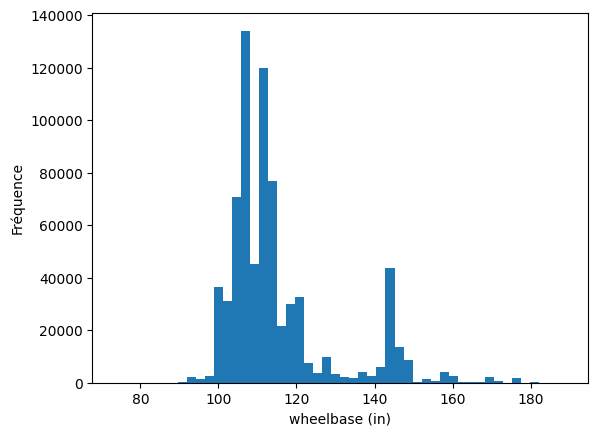

In [93]:
df_train = df_train.drop(['wheelbase'], axis=1)
df_train['wheelbase (in)'] = df_train['wheelbase (in)'].fillna(115.07) #mean

plt.figure()
plt.hist(df_train['wheelbase (in)'], bins=50)
plt.xlabel("wheelbase (in)")
plt.ylabel("Fréquence");

**42. 'width'**

In [94]:
print(df_train['width'].isna().value_counts(normalize=True))
print(df_train['width'].unique())

(df_train['width'] == "--").value_counts(normalize=True)

width
False    0.94892
True     0.05108
Name: proportion, dtype: float64
<StringArray>
['72.4 in',       nan, '69.9 in',   '73 in', '84.2 in', '96.8 in', '66.9 in',
 '71.8 in', '90.4 in',   '82 in',
 ...
 '64.2 in',  '101 in',   '63 in', '89.1 in', '87.6 in', '68.2 in',   '64 in',
 '96.1 in', '62.6 in', '68.4 in']
Length: 272, dtype: str


width
False    0.999864
True     0.000136
Name: proportion, dtype: float64

5% de valeurs manquantes que l'on remplace par la moyenne avec même traitement que "back_legroom"

In [95]:
df_train['width (in)'] = (
    df_train['width']
    .str.replace(" in", "", regex=False)
    .replace("--", np.nan, regex=False)
    .astype(float)
)

df_train['width (in)'].describe()

count    688559.000000
mean         78.642299
std           7.774321
min          57.000000
25%          72.400000
50%          77.700000
75%          83.500000
max         109.000000
Name: width (in), dtype: float64

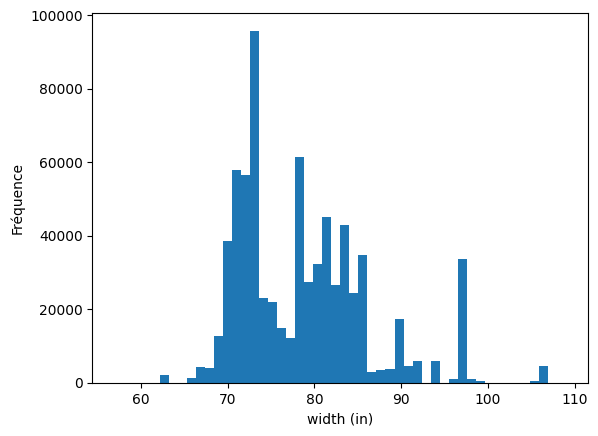

In [96]:
df_train = df_train.drop(['width'], axis=1)
df_train['width (in)'] = df_train['width (in)'].fillna(78.64) #mean

plt.figure()
plt.hist(df_train['width (in)'], bins=50)
plt.xlabel("width (in)")
plt.ylabel("Fréquence");

**43. 'year'**

In [97]:
print(df_train['year'].isna().value_counts(normalize=True))
print(df_train['year'].nunique())

year
False    1.0
Name: proportion, dtype: float64
93


Au final nous obtenons cette base de données (même nombre d'observations et 28 variables) :

In [98]:
print(df_train.info())
df_train.head(5)

<class 'pandas.DataFrame'>
Index: 725728 entries, 762868 to 121958
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   body_type               725728 non-null  str    
 1   city_fuel_economy       725728 non-null  float64
 2   daysonmarket            725728 non-null  int64  
 3   engine_cylinders        725728 non-null  str    
 4   engine_displacement     725728 non-null  float64
 5   franchise_dealer        725728 non-null  bool   
 6   franchise_make          725728 non-null  str    
 7   fuel_type               725728 non-null  str    
 8   highway_fuel_economy    725728 non-null  float64
 9   horsepower              725728 non-null  float64
 10  is_new                  725728 non-null  bool   
 11  listing_color           725728 non-null  str    
 12  maximum_seating         725728 non-null  float64
 13  mileage                 725728 non-null  float64
 14  price                   725728 

,body_type,city_fuel_economy,daysonmarket,engine_cylinders,engine_displacement,franchise_dealer,franchise_make,fuel_type,highway_fuel_economy,horsepower,...,back_legroom (in),front_legroom (in),fuel_tank_volume (gal),height (in),length (in),power (RPM),torque (RPM),torque (lb-ft),wheelbase (in),width (in)
762868,SUV / Crossover,21.0,41,I4,2000.0,False,Ford,Gasoline,26.0,252.0,...,39.70,40.90,15.60,65.4,182.30,5500.0,2000.0,260.0,107.30,72.40
579012,Autres,127.0,19,I4,2500.0,True,Chevrolet,Autres,110.0,240.0,...,38.14,42.19,18.26,66.0,193.07,5761.1,4000.0,258.0,115.07,78.64
668443,SUV / Crossover,26.0,55,I4,1400.0,True,Chevrolet,Gasoline,31.0,138.0,...,35.70,40.80,14.00,66.0,167.60,4900.0,200.0,148.0,100.60,69.90
692273,SUV / Crossover,27.0,62,I4,2500.0,True,Toyota,Gasoline,35.0,203.0,...,37.80,41.00,14.50,67.0,180.90,5761.1,4000.0,258.0,105.90,73.00
885904,Sedan,28.0,1,I4,2500.0,True,Toyota,Gasoline,39.0,203.0,...,38.00,42.10,16.00,56.9,192.10,5761.1,4000.0,258.0,111.20,72.40


### Valeurs extrêmes :

**1. 'daysonmarket'**

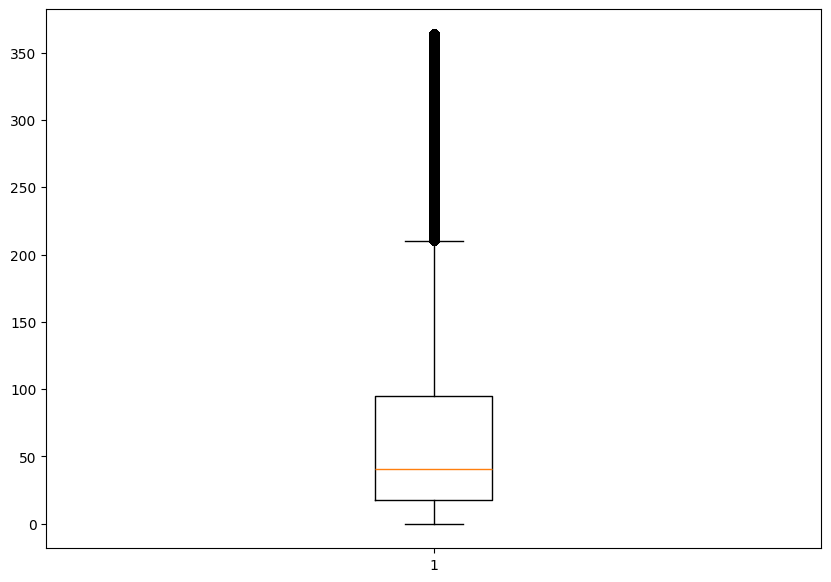

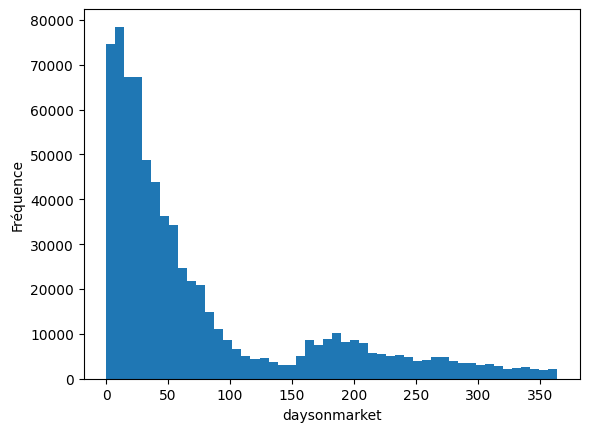

In [116]:
fig = plt.figure(figsize =(10, 7))
plt.boxplot(df_train['daysonmarket'])
plt.show()

plt.figure()
plt.hist(df_train['daysonmarket'], bins=50)
plt.xlabel("daysonmarket")
plt.ylabel("Fréquence");

In [131]:
df_train['daysonmarket'] = df_train['daysonmarket'].clip(0,250)

**2. 'highway_fuel_economy'**

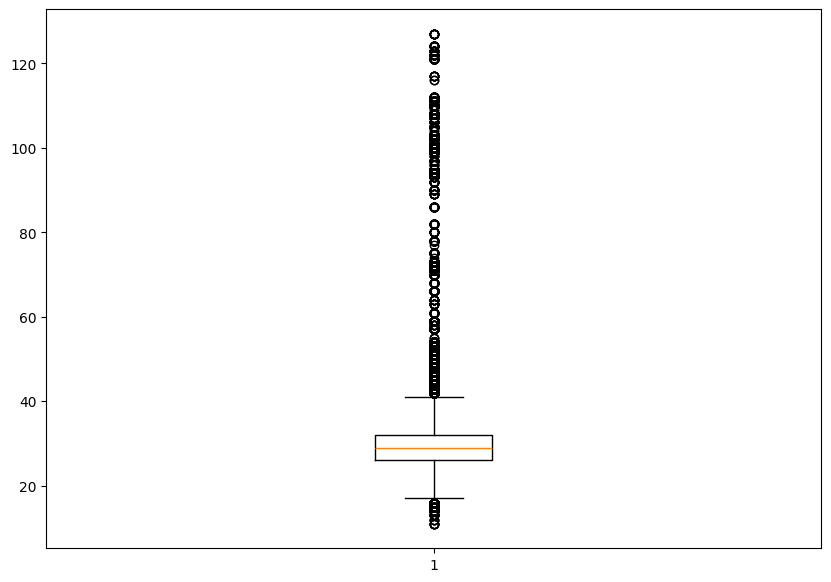

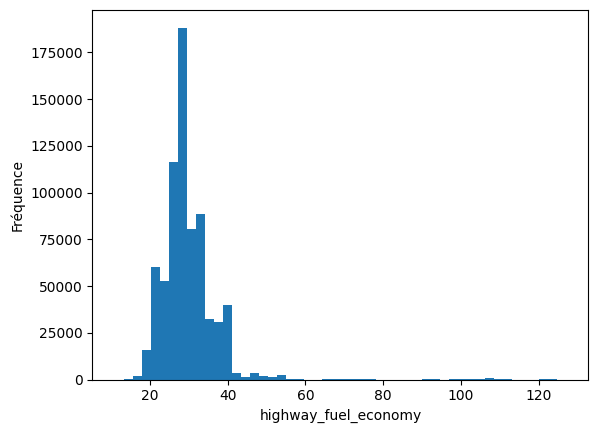

In [118]:
fig = plt.figure(figsize =(10, 7))
plt.boxplot(df_train['highway_fuel_economy'])
plt.show()

plt.figure()
plt.hist(df_train['highway_fuel_economy'], bins=50)
plt.xlabel("highway_fuel_economy")
plt.ylabel("Fréquence");

In [132]:
df_train['highway_fuel_economy'] = df_train['highway_fuel_economy'].clip(15,50)

**3. 'horsepower'**

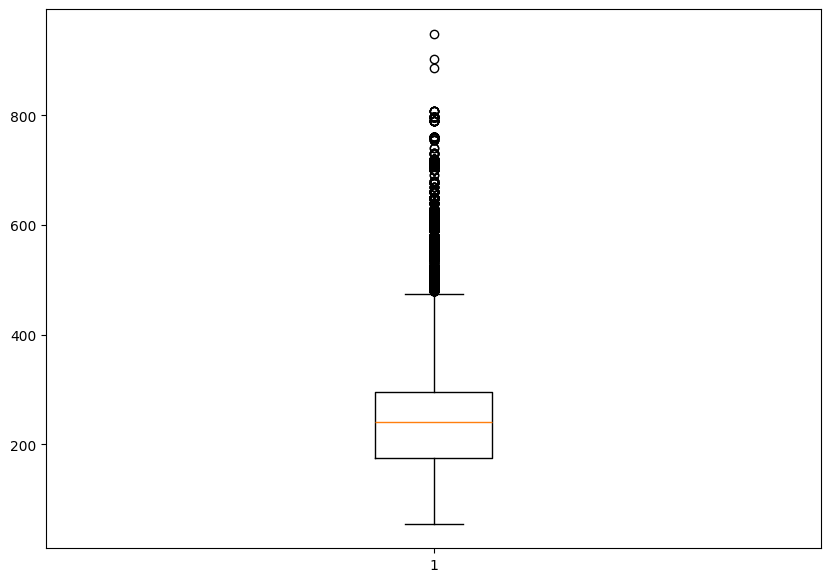

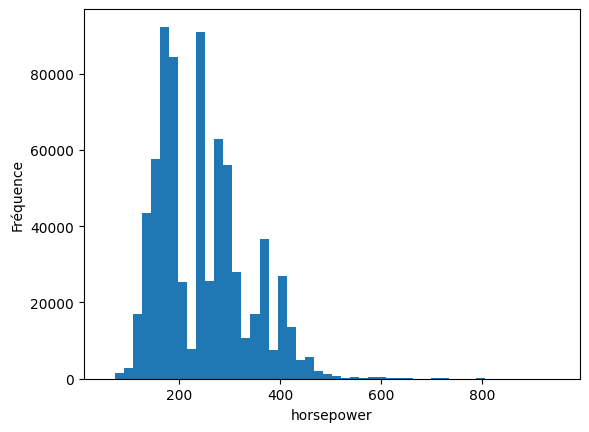

In [119]:
fig = plt.figure(figsize =(10, 7))
plt.boxplot(df_train['horsepower'])
plt.show()

plt.figure()
plt.hist(df_train['horsepower'], bins=50)
plt.xlabel("horsepower")
plt.ylabel("Fréquence");

In [133]:
df_train['horsepower'] = df_train['horsepower'].clip(0,500)

**4. 'maximum_seating'**

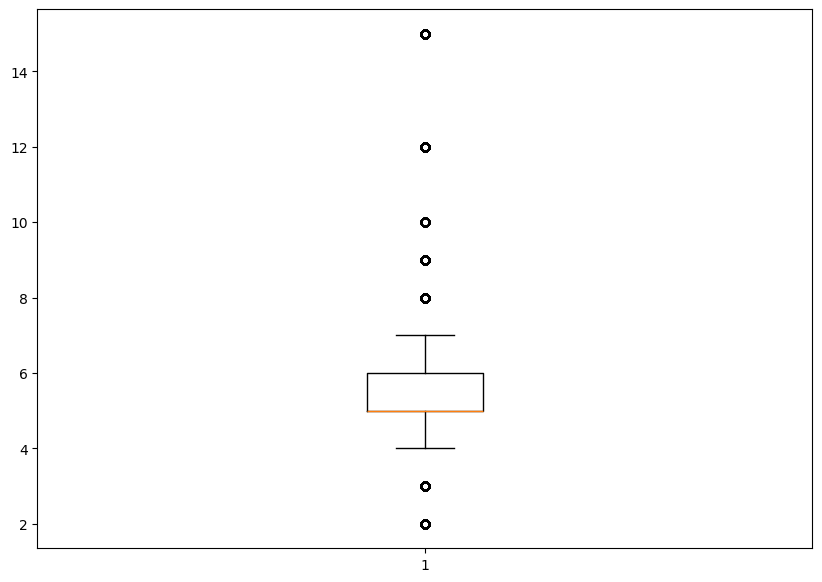

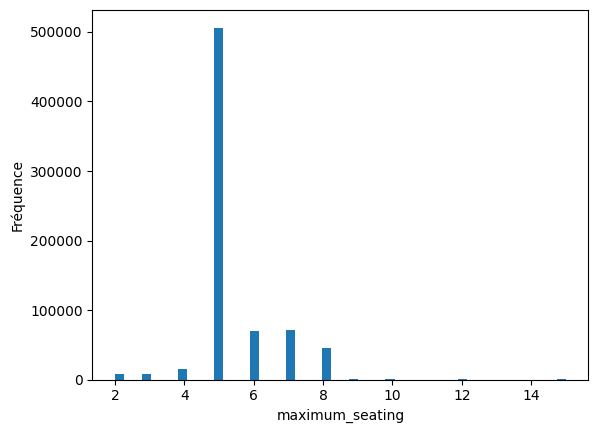

In [120]:
fig = plt.figure(figsize =(10, 7))
plt.boxplot(df_train['maximum_seating'])
plt.show()

plt.figure()
plt.hist(df_train['maximum_seating'], bins=50)
plt.xlabel("maximum_seating")
plt.ylabel("Fréquence");

In [134]:
df_train['maximum_seating'] = df_train['maximum_seating'].clip(4,8)

**5. 'mileage'**

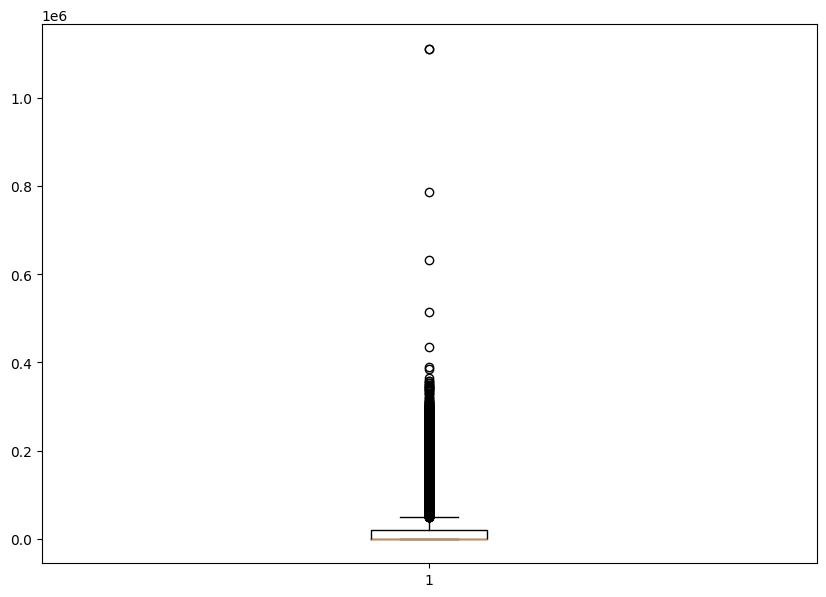

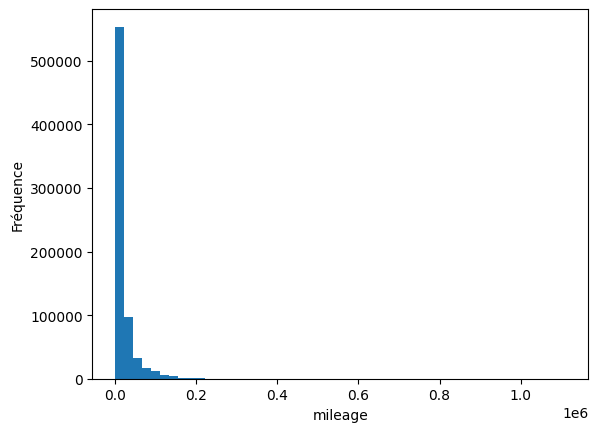

In [121]:
fig = plt.figure(figsize =(10, 7))
plt.boxplot(df_train['mileage'])
plt.show()

plt.figure()
plt.hist(df_train['mileage'], bins=50)
plt.xlabel("mileage")
plt.ylabel("Fréquence");

In [135]:
df_train['mileage'] = df_train['mileage'].clip(0,150000)

**6. 'price'**

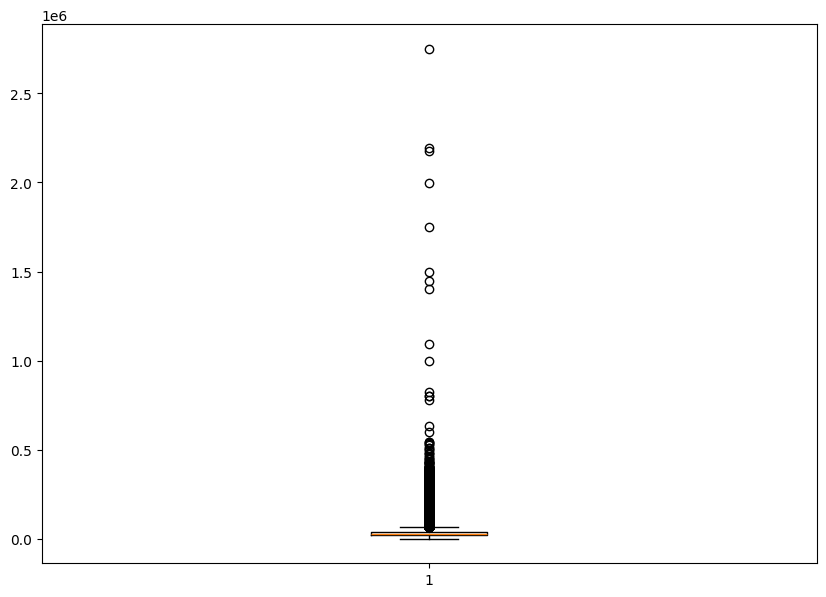

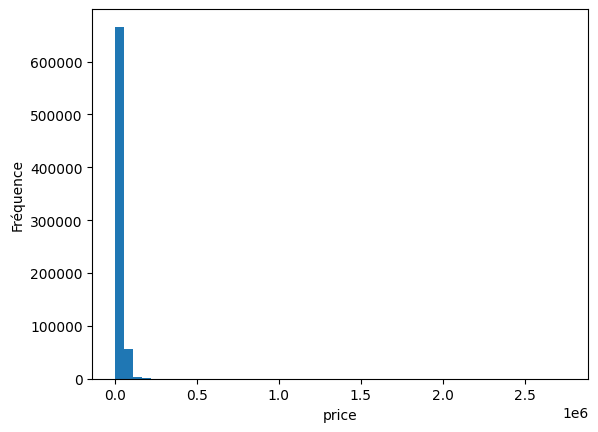

In [122]:
fig = plt.figure(figsize=(10, 7))
plt.boxplot(df_train['price'])
plt.show()

plt.figure()
plt.hist(df_train['price'], bins=50)
plt.xlabel("price")
plt.ylabel("Fréquence");

In [136]:
df_train['price'] = df_train['price'].clip(0,250000)

**7. 'back_legroom (in) '**

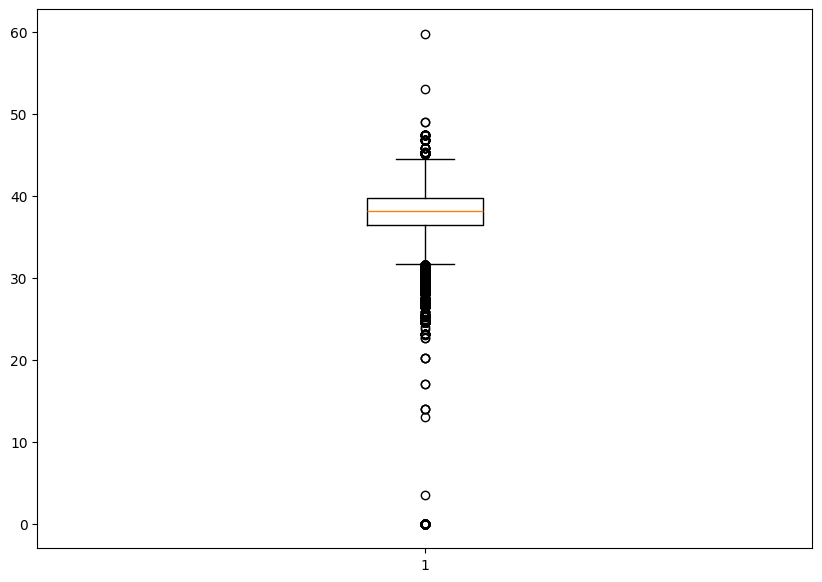

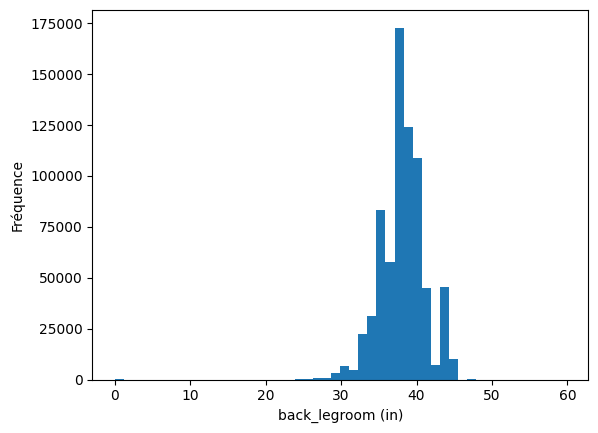

In [124]:
fig = plt.figure(figsize=(10, 7))
plt.boxplot(df_train['back_legroom (in)'])
plt.show()

plt.figure()
plt.hist(df_train['back_legroom (in)'], bins=50)
plt.xlabel("back_legroom (in)")
plt.ylabel("Fréquence");

In [137]:
df_train['back_legroom (in)'] = df_train['back_legroom (in)'].clip(30,45)

**8. 'front_legroom (in)'**

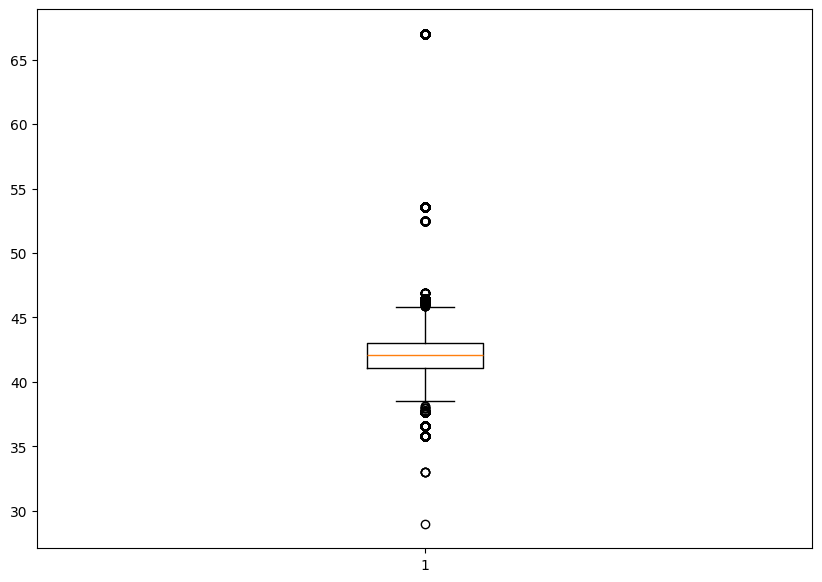

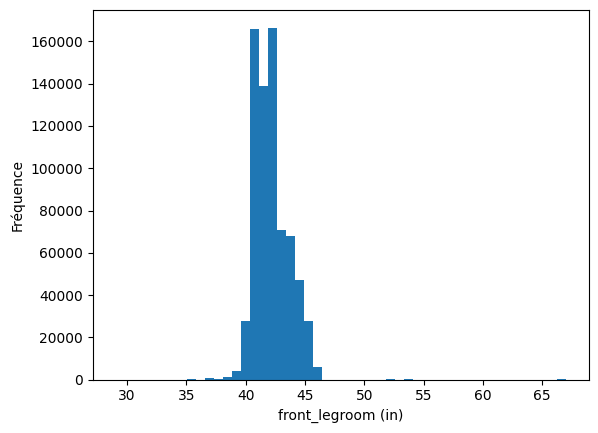

In [125]:
fig = plt.figure(figsize=(10, 7))
plt.boxplot(df_train['front_legroom (in)'])
plt.show()

plt.figure()
plt.hist(df_train['front_legroom (in)'], bins=50)
plt.xlabel("front_legroom (in)")
plt.ylabel("Fréquence");

In [138]:
df_train['front_legroom (in)'] = df_train['front_legroom (in)'].clip(38,47)

**9. 'height (in)'**

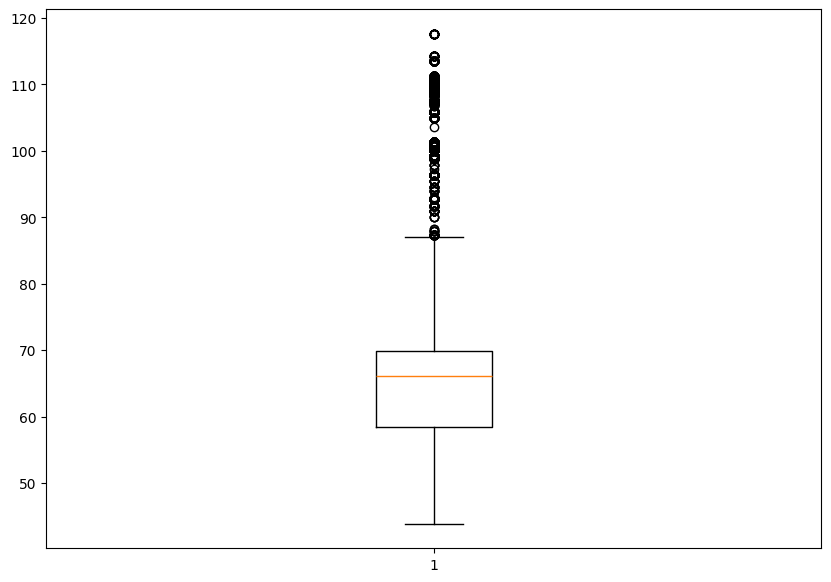

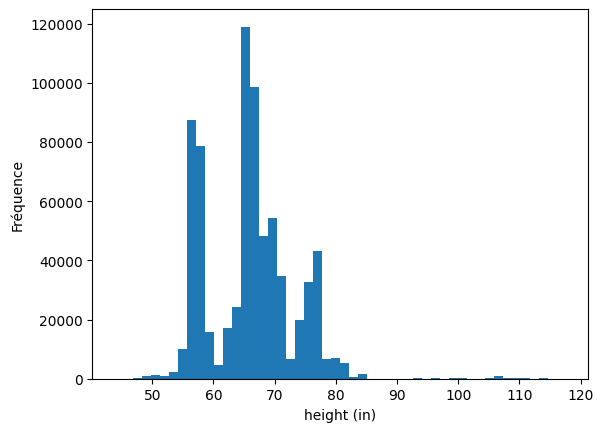

In [126]:
fig = plt.figure(figsize=(10, 7))
plt.boxplot(df_train['height (in)'])
plt.show()

plt.figure()
plt.hist(df_train['height (in)'], bins=50)
plt.xlabel("height (in)")
plt.ylabel("Fréquence");

In [139]:
df_train['height (in)'] = df_train['height (in)'].clip(0,85)

**10. 'power (RPM)'**

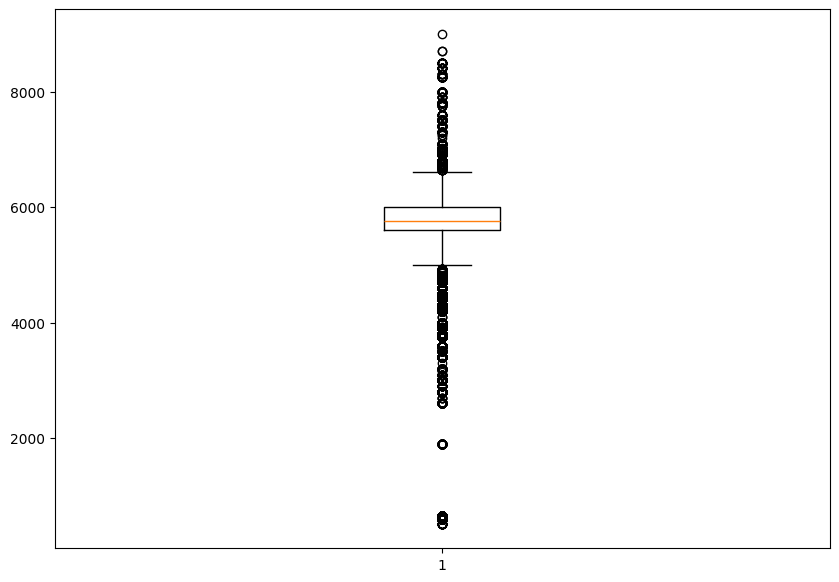

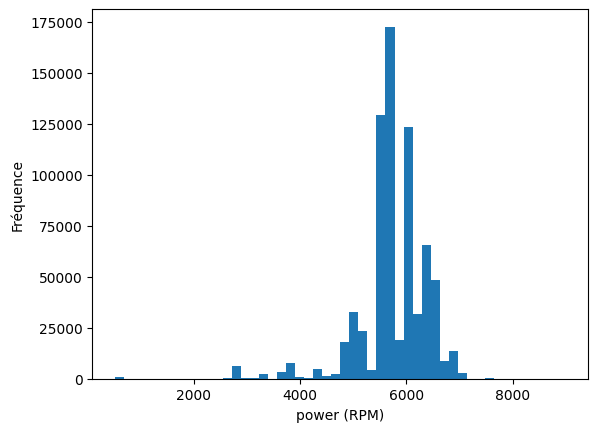

In [127]:
fig = plt.figure(figsize=(10, 7))
plt.boxplot(df_train['power (RPM)'])
plt.show()

plt.figure()
plt.hist(df_train['power (RPM)'], bins=50)
plt.xlabel("power (RPM)")
plt.ylabel("Fréquence");

In [140]:
df_train['power (RPM)'] = df_train['power (RPM)'].clip(4500,6500)

**11. 'torque (RPM)'**

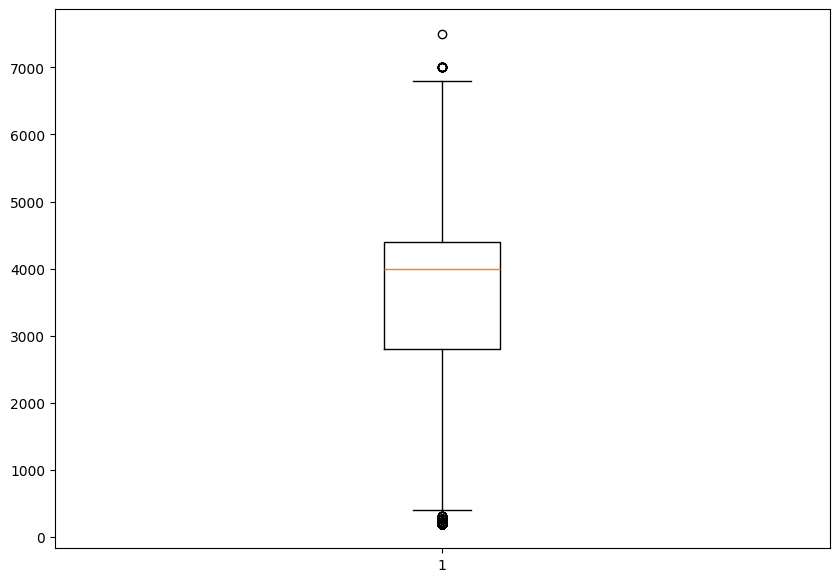

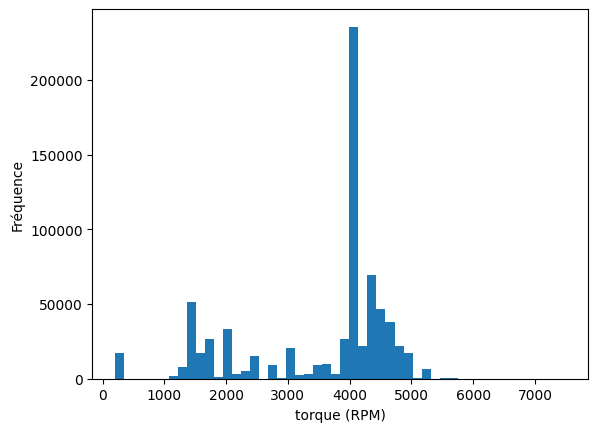

In [128]:
fig = plt.figure(figsize=(10, 7))
plt.boxplot(df_train['torque (RPM)'])
plt.show()

plt.figure()
plt.hist(df_train['torque (RPM)'], bins=50)
plt.xlabel("torque (RPM)")
plt.ylabel("Fréquence");

In [141]:
df_train['torque (RPM)'] = df_train['torque (RPM)'].clip(500,6500)

**12. 'width (in)'**

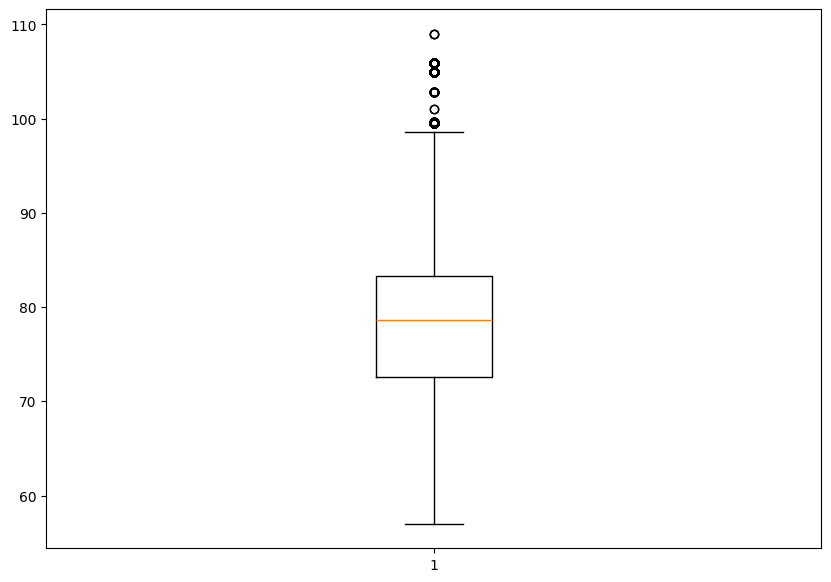

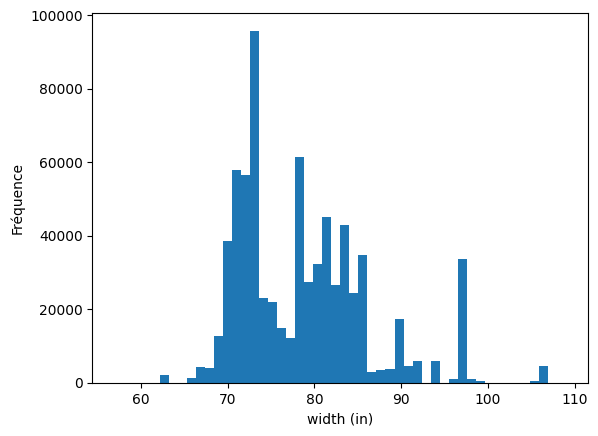

In [129]:
fig = plt.figure(figsize=(10, 7))
plt.boxplot(df_train['width (in)'])
plt.show()

plt.figure()
plt.hist(df_train['width (in)'], bins=50)
plt.xlabel("width (in)")
plt.ylabel("Fréquence");

In [142]:
df_train['width (in)'] = df_train['width (in)'].clip(0,95)